In [1]:
# === CELL 1: Imports and Data Loading ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style settings for plots
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv('Indicators_of_Anxiety_or_Depression.csv')
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df

Dataset shape: (16092, 14)
Rows: 16092, Columns: 14


,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range
0,Symptoms of Depressive Disorder,National Estimate,United States,United States,1.0,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,23.5,22.7,24.3,22.7 - 24.3,NaN
1,Symptoms of Depressive Disorder,By Age,United States,18 - 29 years,1.0,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,32.7,30.2,35.2,30.2 - 35.2,NaN
2,Symptoms of Depressive Disorder,By Age,United States,30 - 39 years,1.0,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,25.7,24.1,27.3,24.1 - 27.3,NaN
3,Symptoms of Depressive Disorder,By Age,United States,40 - 49 years,1.0,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,24.8,23.3,26.2,23.3 - 26.2,NaN
4,Symptoms of Depressive Disorder,By Age,United States,50 - 59 years,1.0,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,23.2,21.5,25.0,21.5 - 25.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16087,Symptoms of Anxiety Disorder or Depressive Dis...,By State,Virginia,Virginia,4.1,69,"May 28 - Jun 24, 2024",05/28/2024,06/24/2024,20.7,17.9,23.8,17.9 - 23.8,19.2-20.8
16088,Symptoms of Anxiety Disorder or Depressive Dis...,By State,Washington,Washington,4.1,69,"May 28 - Jun 24, 2024",05/28/2024,06/24/2024,20.3,17.5,23.4,17.5 - 23.4,19.2-20.8
16089,Symptoms of Anxiety Disorder or Depressive Dis...,By State,West Virginia,West Virginia,4.1,69,"May 28 - Jun 24, 2024",05/28/2024,06/24/2024,22.8,19.2,26.8,19.2 - 26.8,22.4-24.6
16090,Symptoms of Anxiety Disorder or Depressive Dis...,By State,Wisconsin,Wisconsin,4.1,69,"May 28 - Jun 24, 2024",05/28/2024,06/24/2024,18.9,15.6,22.6,15.6 - 22.6,14.8-19.1


In [2]:
# === CELL 2: Data Types and General Info ===
print("DATA TYPES")
print("-" * 33)
print(df.dtypes)

print("\n")
print("BASIC STATISTICS (numerical columns)")
print("-" * 60)
df.describe()

DATA TYPES
---------------------------------
Indicator                  object
Group                      object
State                      object
Subgroup                   object
Phase                      object
Time Period                 int64
Time Period Label          object
Time Period Start Date     object
Time Period End Date       object
Value                     float64
Low CI                    float64
High CI                   float64
Confidence Interval        object
Quartile Range             object
dtype: object


BASIC STATISTICS (numerical columns)
------------------------------------------------------------


,Time Period,Value,Low CI,High CI
count,16092.000000,15386.000000,15386.000000,15386.000000
mean,34.392617,28.583979,25.058735,32.358612
std,20.681589,8.775480,8.446655,9.282907
min,1.000000,4.700000,3.300000,6.000000
25%,16.000000,22.700000,19.300000,26.100000
50%,35.000000,28.100000,24.500000,32.000000
75%,52.000000,33.600000,30.000000,37.700000
max,69.000000,85.200000,79.900000,89.500000


In [3]:
# === CELL 3: Missing Values Analysis ===
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print("MISSING VALUES SUMMARY")
print("=" * 45)
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Rows with at least 1 missing value: {df.isnull().any(axis=1).sum()}")

# Checking where do missing Values come from
print("\nPhase distribution for rows where Value is missing:")
print(df[df['Value'].isnull()]['Phase'].value_counts())
print("\n=> 702/706 missing Values come from Phase = '-1' (no data collected)")

MISSING VALUES SUMMARY
                     Missing Count  Missing %
Quartile Range                5534      34.39
Value                          706       4.39
Low CI                         706       4.39
High CI                        706       4.39
Confidence Interval            706       4.39

Total missing values: 8358
Rows with at least 1 missing value: 5535

Phase distribution for rows where Value is missing:
Phase
-1     702
4.1      3
4.0      1
Name: count, dtype: int64

=> 702/706 missing Values come from Phase = '-1' (no data collected)


In [4]:
df[df['Value'].isnull()]

,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range
2520,Symptoms of Depressive Disorder,National Estimate,United States,United States,-1,1,"July 22 - Aug 18, 2020",07/22/2020,08/18/2020,NaN,NaN,NaN,NaN,NaN
2521,Symptoms of Depressive Disorder,By Age,United States,18 - 29 years,-1,1,"July 22 - Aug 18, 2020",07/22/2020,08/18/2020,NaN,NaN,NaN,NaN,NaN
2522,Symptoms of Depressive Disorder,By Age,United States,30 - 39 years,-1,1,"July 22 - Aug 18, 2020",07/22/2020,08/18/2020,NaN,NaN,NaN,NaN,NaN
2523,Symptoms of Depressive Disorder,By Age,United States,40 - 49 years,-1,1,"July 22 - Aug 18, 2020",07/22/2020,08/18/2020,NaN,NaN,NaN,NaN,NaN
2524,Symptoms of Depressive Disorder,By Age,United States,50 - 59 years,-1,1,"July 22 - Aug 18, 2020",07/22/2020,08/18/2020,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14843,Symptoms of Anxiety Disorder or Depressive Dis...,By Disability status,United States,Without disability,-1,1,"Nov 27, 2023 - Jan 8, 2024",11/27/2023,01/08/2024,NaN,NaN,NaN,NaN,NaN
15012,Symptoms of Anxiety Disorder,By Gender identity,United States,Transgender,4.0,65,"Feb 6 - Mar 4, 2024",02/06/2024,03/04/2024,NaN,NaN,NaN,NaN,Estimate not reliable
15402,Symptoms of Depressive Disorder,By Gender identity,United States,Transgender,4.1,67,"Apr 2 - Apr 29, 2024",04/02/2024,04/29/2024,NaN,NaN,NaN,NaN,NaN
15480,Symptoms of Anxiety Disorder,By Gender identity,United States,Transgender,4.1,67,"Apr 2 - Apr 29, 2024",04/02/2024,04/29/2024,NaN,NaN,NaN,NaN,NaN


In [5]:
# === CELL 4: Cleaning ===
print(f"Shape before cleaning: {df.shape}")

# 1. Remove rows with Phase = -1 (no data collected for these periods)
df = df[df['Phase'] != '-1']
print(f"After removing Phase = -1: {df.shape}")

# 2. Remove remaining rows with missing Value (only 4 rows)
df = df.dropna(subset=['Value'])
print(f"After removing remaining NaN Values: {df.shape}")

# 3. Parse dates
df['Time Period Start Date'] = pd.to_datetime(df['Time Period Start Date'], format='%m/%d/%Y')
df['Time Period End Date'] = pd.to_datetime(df['Time Period End Date'], format='%m/%d/%Y')

# 4. Extract useful time features
df['Year'] = df['Time Period Start Date'].dt.year
df['Month'] = df['Time Period Start Date'].dt.month

# 5. Drop columns we won't use 
# Confidence Interval is redundant with Low CI / High CI
# Quartile Range only exists for "By State" rows
df_clean = df.drop(columns=['Confidence Interval', 'Quartile Range'])

print(f"\nFinal cleaned shape: {df_clean.shape}")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")
df_clean

Shape before cleaning: (16092, 14)
After removing Phase = -1: (15390, 14)
After removing remaining NaN Values: (15386, 14)

Final cleaned shape: (15386, 14)
Remaining missing values: 0


,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Year,Month
0,Symptoms of Depressive Disorder,National Estimate,United States,United States,1.0,1,"Apr 23 - May 5, 2020",2020-04-23,2020-05-05,23.5,22.7,24.3,2020,4
1,Symptoms of Depressive Disorder,By Age,United States,18 - 29 years,1.0,1,"Apr 23 - May 5, 2020",2020-04-23,2020-05-05,32.7,30.2,35.2,2020,4
2,Symptoms of Depressive Disorder,By Age,United States,30 - 39 years,1.0,1,"Apr 23 - May 5, 2020",2020-04-23,2020-05-05,25.7,24.1,27.3,2020,4
3,Symptoms of Depressive Disorder,By Age,United States,40 - 49 years,1.0,1,"Apr 23 - May 5, 2020",2020-04-23,2020-05-05,24.8,23.3,26.2,2020,4
4,Symptoms of Depressive Disorder,By Age,United States,50 - 59 years,1.0,1,"Apr 23 - May 5, 2020",2020-04-23,2020-05-05,23.2,21.5,25.0,2020,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16087,Symptoms of Anxiety Disorder or Depressive Dis...,By State,Virginia,Virginia,4.1,69,"May 28 - Jun 24, 2024",2024-05-28,2024-06-24,20.7,17.9,23.8,2024,5
16088,Symptoms of Anxiety Disorder or Depressive Dis...,By State,Washington,Washington,4.1,69,"May 28 - Jun 24, 2024",2024-05-28,2024-06-24,20.3,17.5,23.4,2024,5
16089,Symptoms of Anxiety Disorder or Depressive Dis...,By State,West Virginia,West Virginia,4.1,69,"May 28 - Jun 24, 2024",2024-05-28,2024-06-24,22.8,19.2,26.8,2024,5
16090,Symptoms of Anxiety Disorder or Depressive Dis...,By State,Wisconsin,Wisconsin,4.1,69,"May 28 - Jun 24, 2024",2024-05-28,2024-06-24,18.9,15.6,22.6,2024,5


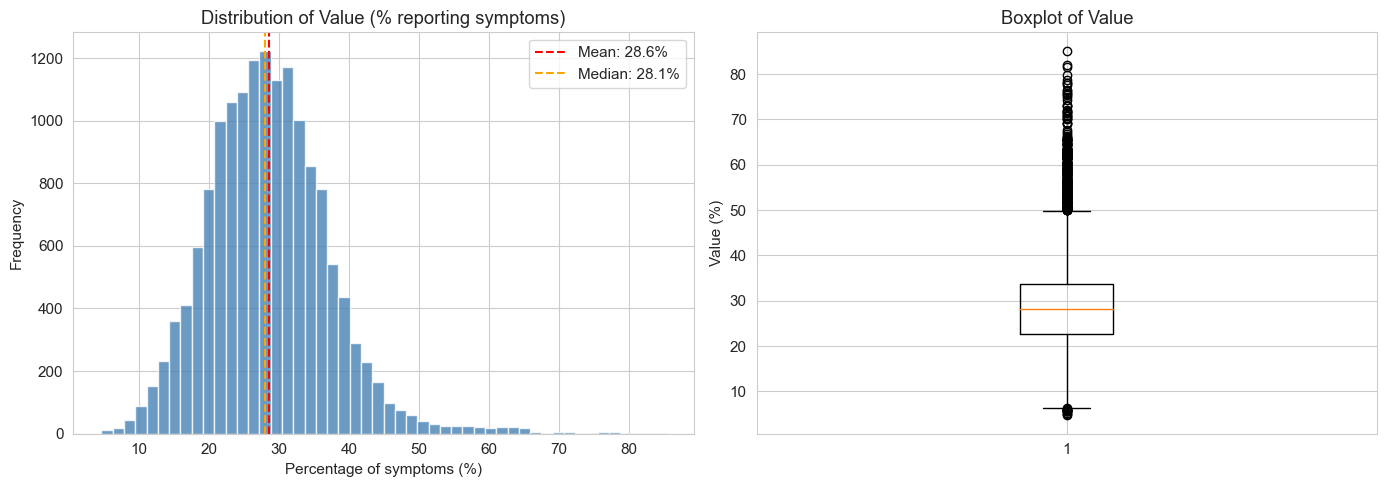

Mean: 28.58%
Std:  8.78%
Min:  4.70%
Max: 85.20%
Skewness: 0.818


In [6]:
# === CELL 5: Distribution of Value (target variable) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['Value'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df_clean['Value'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['Value'].mean():.1f}%")
axes[0].axvline(df_clean['Value'].median(), color='orange', linestyle='--', label=f"Median: {df_clean['Value'].median():.1f}%")
axes[0].set_xlabel('Percentage of symptoms (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Value (% reporting symptoms)')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_clean['Value'], vert=True)
axes[1].set_ylabel('Value (%)')
axes[1].set_title('Boxplot of Value')

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Value'].mean():.2f}%")
print(f"Std:  {df_clean['Value'].std():.2f}%")
print(f"Min:  {df_clean['Value'].min():.2f}%")
print(f"Max: {df_clean['Value'].max():.2f}%")
print(f"Skewness: {df_clean['Value'].skew():.3f}")

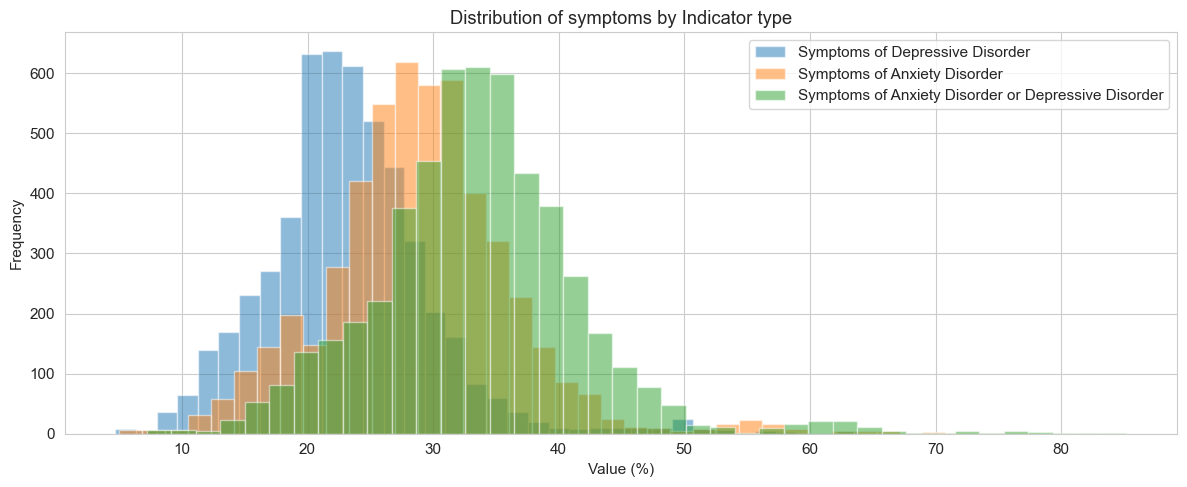

                                                     count   mean   std  min  \
Indicator                                                                      
Symptoms of Anxiety Disorder                        5128.0  28.95  7.74  5.0   
Symptoms of Anxiety Disorder or Depressive Diso...  5129.0  33.55  8.40  7.2   
Symptoms of Depressive Disorder                     5129.0  23.25  6.89  4.7   

                                                      25%   50%   75%   max  
Indicator                                                                    
Symptoms of Anxiety Disorder                        24.68  28.7  32.9  78.1  
Symptoms of Anxiety Disorder or Depressive Diso...  28.80  33.3  37.9  85.2  
Symptoms of Depressive Disorder                     19.40  22.8  26.5  70.4  


In [7]:
# === CELL 6: Value distribution by Indicator ===
fig, ax = plt.subplots(figsize=(12, 5))

for indicator in df_clean['Indicator'].unique():
    subset = df_clean[df_clean['Indicator'] == indicator]['Value']
    ax.hist(subset, bins=40, alpha=0.5, label=indicator)

ax.set_xlabel('Value (%)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of symptoms by Indicator type')
ax.legend()
plt.tight_layout()
plt.show()

# Stats by Indicator
print(df_clean.groupby('Indicator')['Value'].describe().round(2))

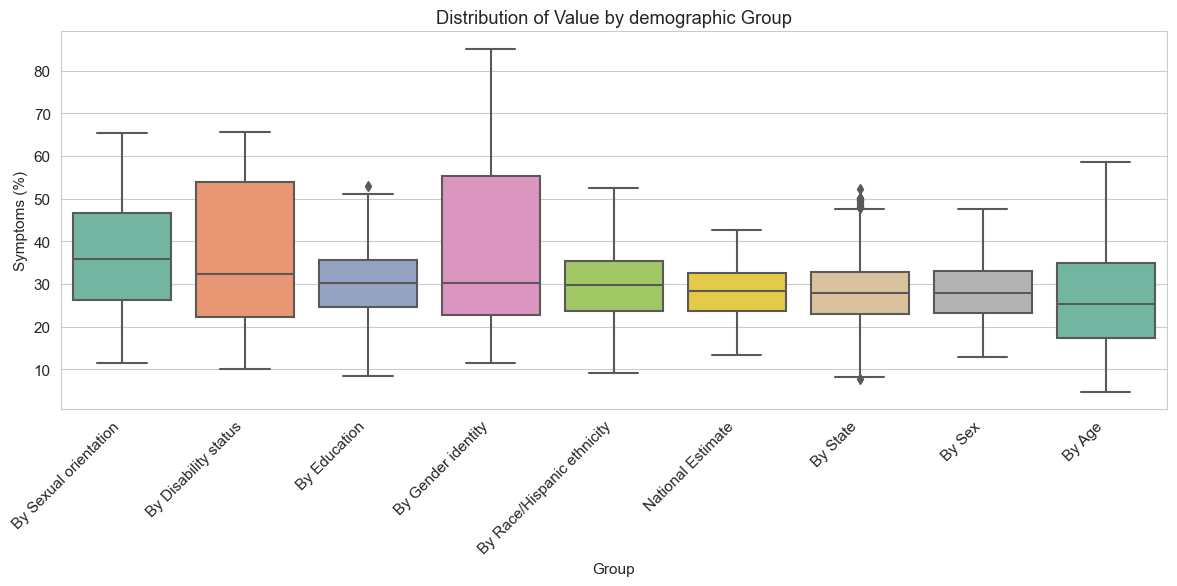


Number of rows per group:
Group
By State                      10557
By Age                         1449
By Race/Hispanic ethnicity     1035
By Education                    828
By Sex                          414
By Sexual orientation           324
By Gender identity              320
By Disability status            252
National Estimate               207
Name: count, dtype: int64


In [8]:
# === CELL 7: Value by Group ===
fig, ax = plt.subplots(figsize=(12, 6))

order = df_clean.groupby('Group')['Value'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='Group', y='Value', order=order, ax=ax, palette='Set2')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Distribution of Value by demographic Group')
ax.set_ylabel('Symptoms (%)')
plt.tight_layout()
plt.show()

# Number of rows per group
print("\nNumber of rows per group:")
print(df_clean['Group'].value_counts())

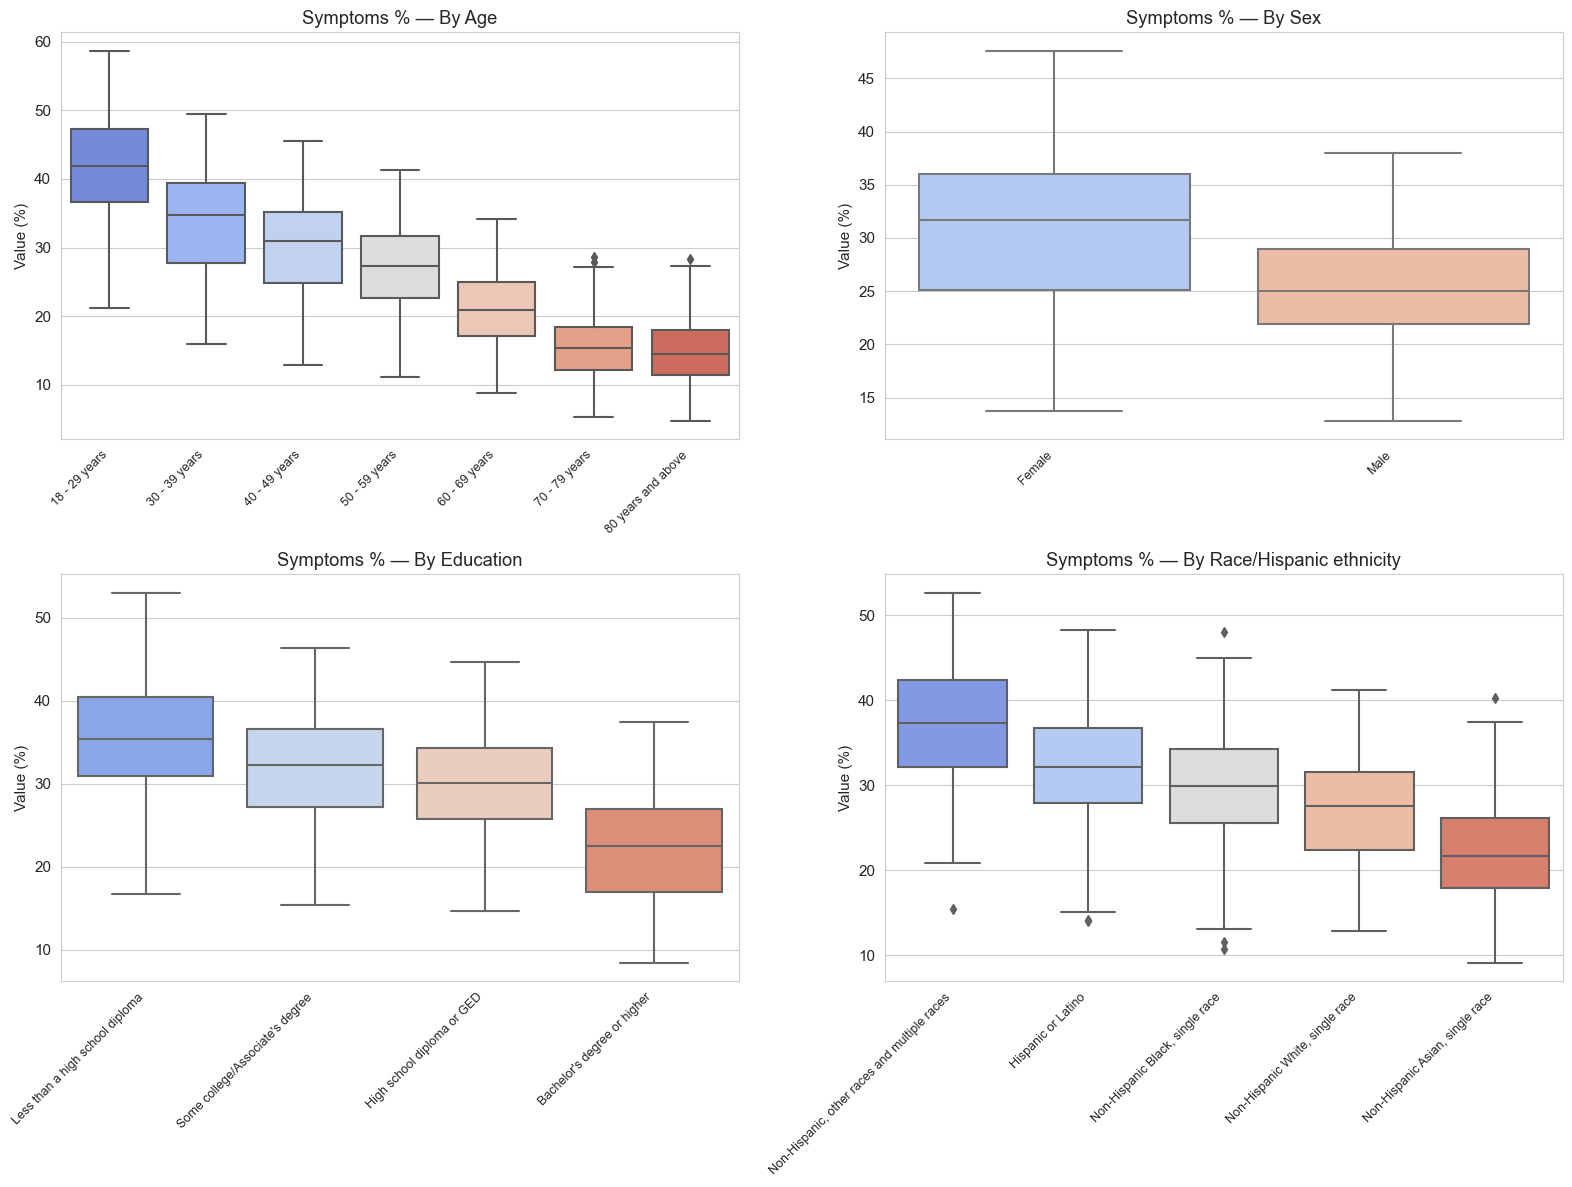

In [9]:
# === CELL 8: Value by Subgroup within each Group ===
groups_to_plot = ['By Age', 'By Sex', 'By Education', 'By Race/Hispanic ethnicity']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, group in enumerate(groups_to_plot):
    subset = df_clean[df_clean['Group'] == group]
    order = subset.groupby('Subgroup')['Value'].median().sort_values(ascending=False).index
    sns.boxplot(data=subset, x='Subgroup', y='Value', order=order, 
                ax=axes[i], palette='coolwarm')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=9)
    axes[i].set_title(f'Symptoms % — {group}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value (%)')

plt.tight_layout()
plt.show()

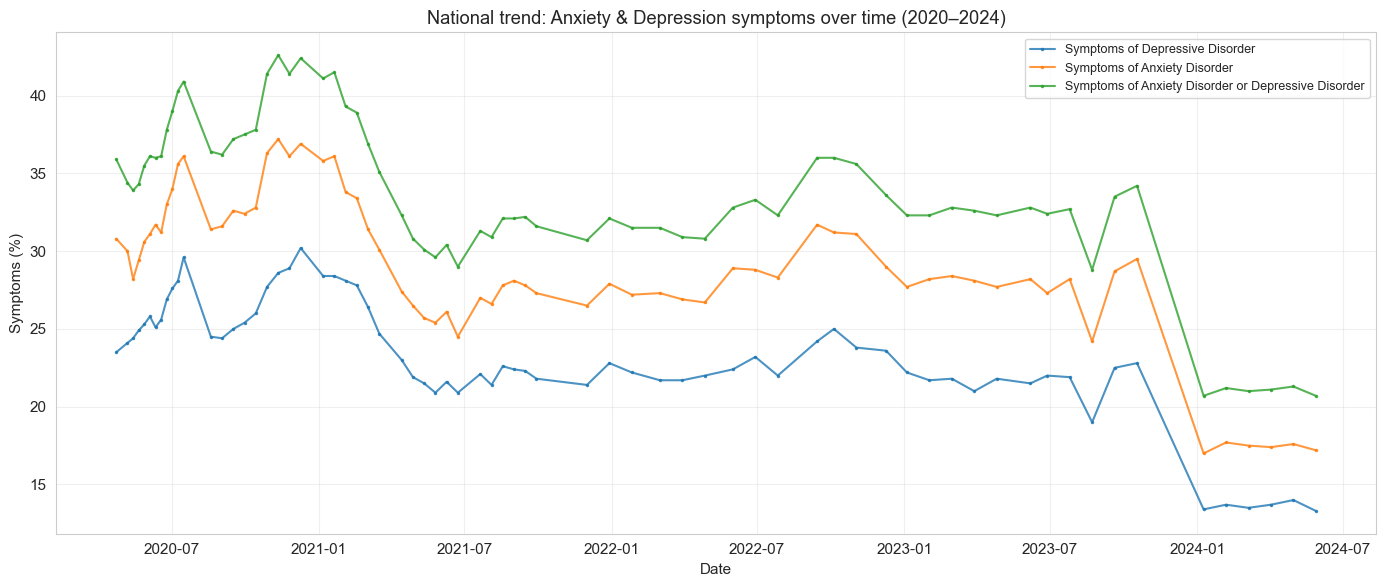

In [10]:
# === CELL 9: Time Series - National Estimate ===
national = df_clean[df_clean['Group'] == 'National Estimate'].copy()

fig, ax = plt.subplots(figsize=(14, 6))

for indicator in national['Indicator'].unique():
    subset = national[national['Indicator'] == indicator].sort_values('Time Period Start Date')
    ax.plot(subset['Time Period Start Date'], subset['Value'], 
            marker='.', markersize=3, label=indicator, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Symptoms (%)')
ax.set_title('National trend: Anxiety & Depression symptoms over time (2020–2024)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

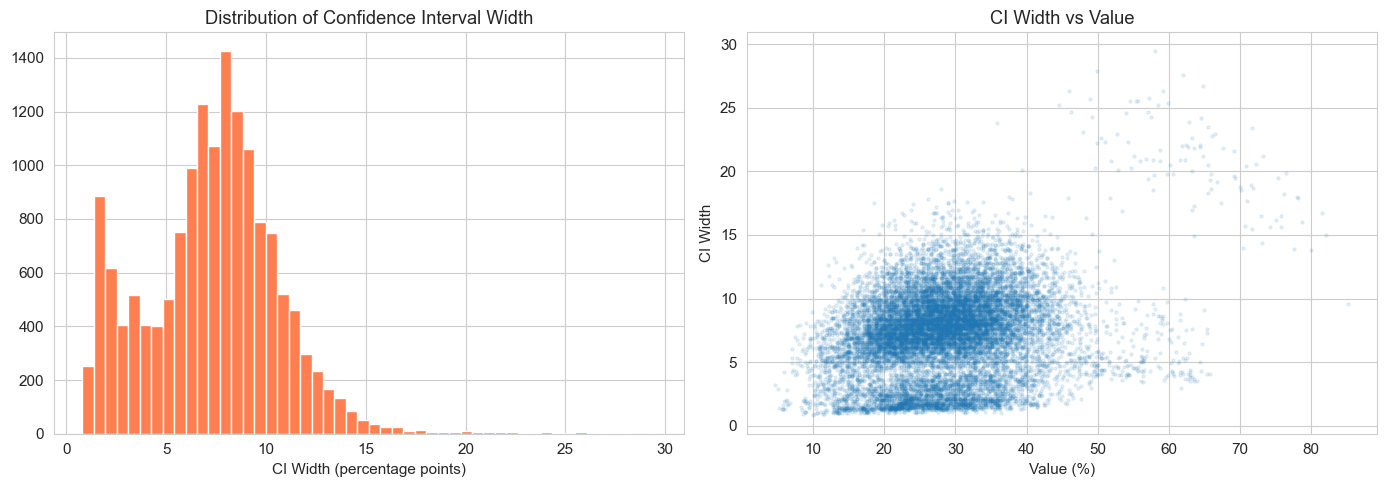

Mean CI width: 7.30 pp
Median CI width: 7.50 pp


In [11]:
# === CELL 10: CI width analysis ===
df_clean['CI_width'] = df_clean['High CI'] - df_clean['Low CI']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CI width distribution
axes[0].hist(df_clean['CI_width'], bins=50, color='coral', edgecolor='white')
axes[0].set_title('Distribution of Confidence Interval Width')
axes[0].set_xlabel('CI Width (percentage points)')

# CI width vs Value
axes[1].scatter(df_clean['Value'], df_clean['CI_width'], alpha=0.1, s=5)
axes[1].set_xlabel('Value (%)')
axes[1].set_ylabel('CI Width')
axes[1].set_title('CI Width vs Value')

plt.tight_layout()
plt.show()

print(f"Mean CI width: {df_clean['CI_width'].mean():.2f} pp")
print(f"Median CI width: {df_clean['CI_width'].median():.2f} pp")

In [12]:
#Teste pour l'annee 2021 uniquement
df_states = pd.read_csv('state_socioeconomic_data.csv')
print("State socioeconomic data:")
print(f"  Shape: {df_states.shape}")
print(f"  Columns: {list(df_states.columns)}")
print()

df_states

State socioeconomic data:
  Shape: (51, 6)
  Columns: ['State', 'median_household_income', 'poverty_rate', 'pct_bachelors_or_higher', 'pct_uninsured', 'unemployment_rate']



,State,median_household_income,poverty_rate,pct_bachelors_or_higher,pct_uninsured,unemployment_rate
0,Alabama,53913.0,16.1,27.4,9.9,5.3
1,Alaska,77845.0,10.5,32.8,11.4,7.0
2,Arizona,69056.0,12.8,32.4,10.7,5.8
3,Arkansas,52528.0,16.3,25.3,9.2,5.5
4,California,84907.0,12.3,36.2,7.0,8.3
5,Colorado,82254.0,9.7,44.4,8.0,5.3
6,Connecticut,83771.0,10.1,42.1,5.2,6.7
7,Delaware,71091.0,11.6,35.6,5.7,5.6
8,District of Columbia,90088.0,16.5,63.0,3.7,8.2
9,Florida,63062.0,13.1,33.2,12.1,5.6


In [13]:
# === CELL 12: Load & Merge State Socioeconomic Data (2020-2024) ===
import pandas as pd
import numpy as np

# 1. Loading the new file (2020-2024) instaed of only 2021
df_states = pd.read_csv('master_socioeconomic_data_2020_2024.csv')
print("State socioeconomic data (Multi-year):")
print(f"  Shape: {df_states.shape}")
print(f"  Columns: {list(df_states.columns)}\n")

# 2. Ensure that our dataset has a column 'Year'
if 'Year' not in df_clean.columns:
    df_clean['Time Period Start Date'] = pd.to_datetime(df_clean['Time Period Start Date'])
    df_clean['Year'] = df_clean['Time Period Start Date'].dt.year

state_rows = df_clean[df_clean['Group'] == 'By State']
dataset_states = set(state_rows['Subgroup'].unique())
enrichment_states = set(df_states['State'].unique())

print(f"States in our dataset: {len(dataset_states)}")
print(f"States in enrichment file: {len(enrichment_states)}")
print(f"Match: {dataset_states == enrichment_states}\n")

# 3. Merging on State and on Year
df_enriched = df_clean.merge(
    df_states, 
    left_on=['Subgroup', 'Year'], 
    right_on=['State', 'Year'], 
    how='left'
)

# Delete redundant column State (because of the merge we did before)
if 'State' in df_enriched.columns and 'Subgroup' in df_enriched.columns:
    df_enriched.drop(columns=['State'], inplace=True)

print(f"Enriched dataset shape: {df_enriched.shape}")
print(f"New columns added: {[c for c in df_states.columns if c not in ['State', 'Year']]}")
print(f"Non-null socioeconomic rows: {df_enriched['median_household_income'].notna().sum()}")

State socioeconomic data (Multi-year):
  Shape: (259, 7)
  Columns: ['State', 'median_household_income', 'poverty_rate', 'pct_bachelors_or_higher', 'pct_uninsured', 'unemployment_rate', 'Year']

States in our dataset: 51
States in enrichment file: 52
Match: False

Enriched dataset shape: (15386, 21)
New columns added: ['median_household_income', 'poverty_rate', 'pct_bachelors_or_higher', 'pct_uninsured', 'unemployment_rate']
Non-null socioeconomic rows: 10557


In [14]:
# === CELL 13: Overview of Enriched State Data ===
df_state = df_enriched[df_enriched['Group'] == 'By State'].copy()
print(f"State-level subset (2020-2024): {df_state.shape}\n")

socio_cols = ['median_household_income', 'poverty_rate', 
              'pct_bachelors_or_higher', 'pct_uninsured', 'unemployment_rate']

print("Descriptive statistics of socioeconomic features (2020-2024):")
print(df_state[socio_cols].describe().round(2))

State-level subset (2020-2024): (10557, 21)

Descriptive statistics of socioeconomic features (2020-2024):
       median_household_income  poverty_rate  pct_bachelors_or_higher  \
count                 10557.00      10557.00                 10557.00   
mean                  71188.53         12.45                    34.43   
std                   12912.11          2.64                     6.81   
min                   46511.00          7.20                    21.30   
25%                   61847.00         10.40                    30.10   
50%                   69543.00         12.00                    33.50   
75%                   79855.00         13.90                    37.50   
max                  109707.00         19.60                    65.90   

       pct_uninsured  unemployment_rate  
count       10557.00           10557.00  
mean            7.69               4.84  
std             2.89               1.37  
min             2.40               1.90  
25%             5.60     

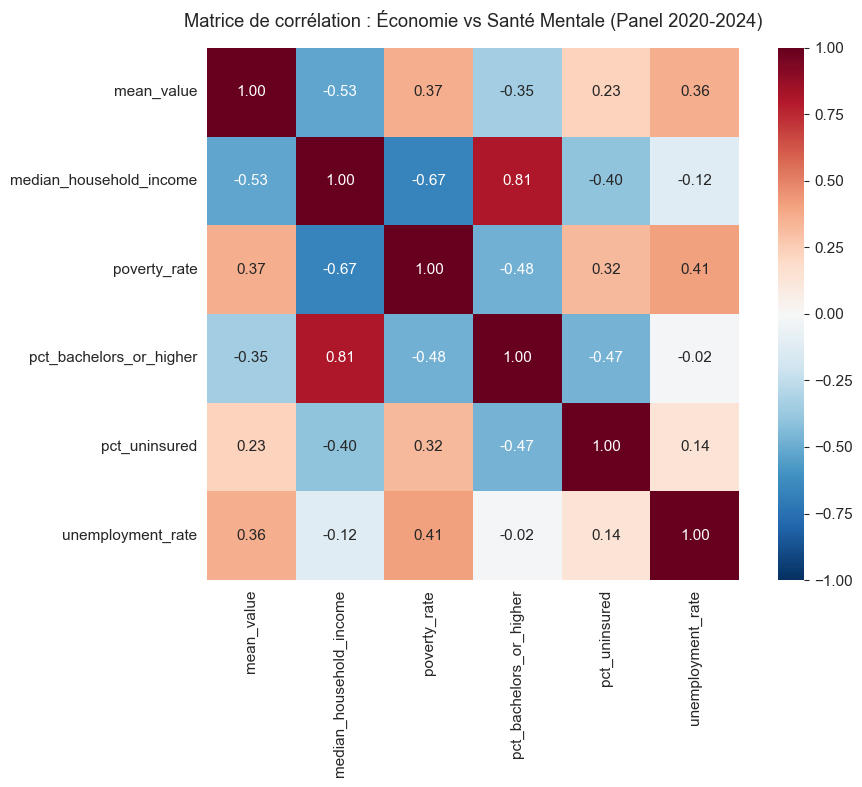

In [15]:
# === CELL 14: Correlation - Socioeconomic Features vs Symptom Rate ===
import matplotlib.pyplot as plt
import seaborn as sns

# Group by State and by Year to capture the dynamic evolution
state_year_avg = df_state.groupby(['Subgroup', 'Year']).agg(
    mean_value=('Value', 'mean'),
    median_household_income=('median_household_income', 'first'),
    poverty_rate=('poverty_rate', 'first'),
    pct_bachelors_or_higher=('pct_bachelors_or_higher', 'first'),
    pct_uninsured=('pct_uninsured', 'first'),
    unemployment_rate=('unemployment_rate', 'first'),
).reset_index()

# Correlation matrix
corr_cols = ['mean_value'] + socio_cols
corr_matrix = state_year_avg[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Matrice de corrélation : Économie vs Santé Mentale (Panel 2020-2024)', pad=15)
plt.tight_layout()
plt.show()

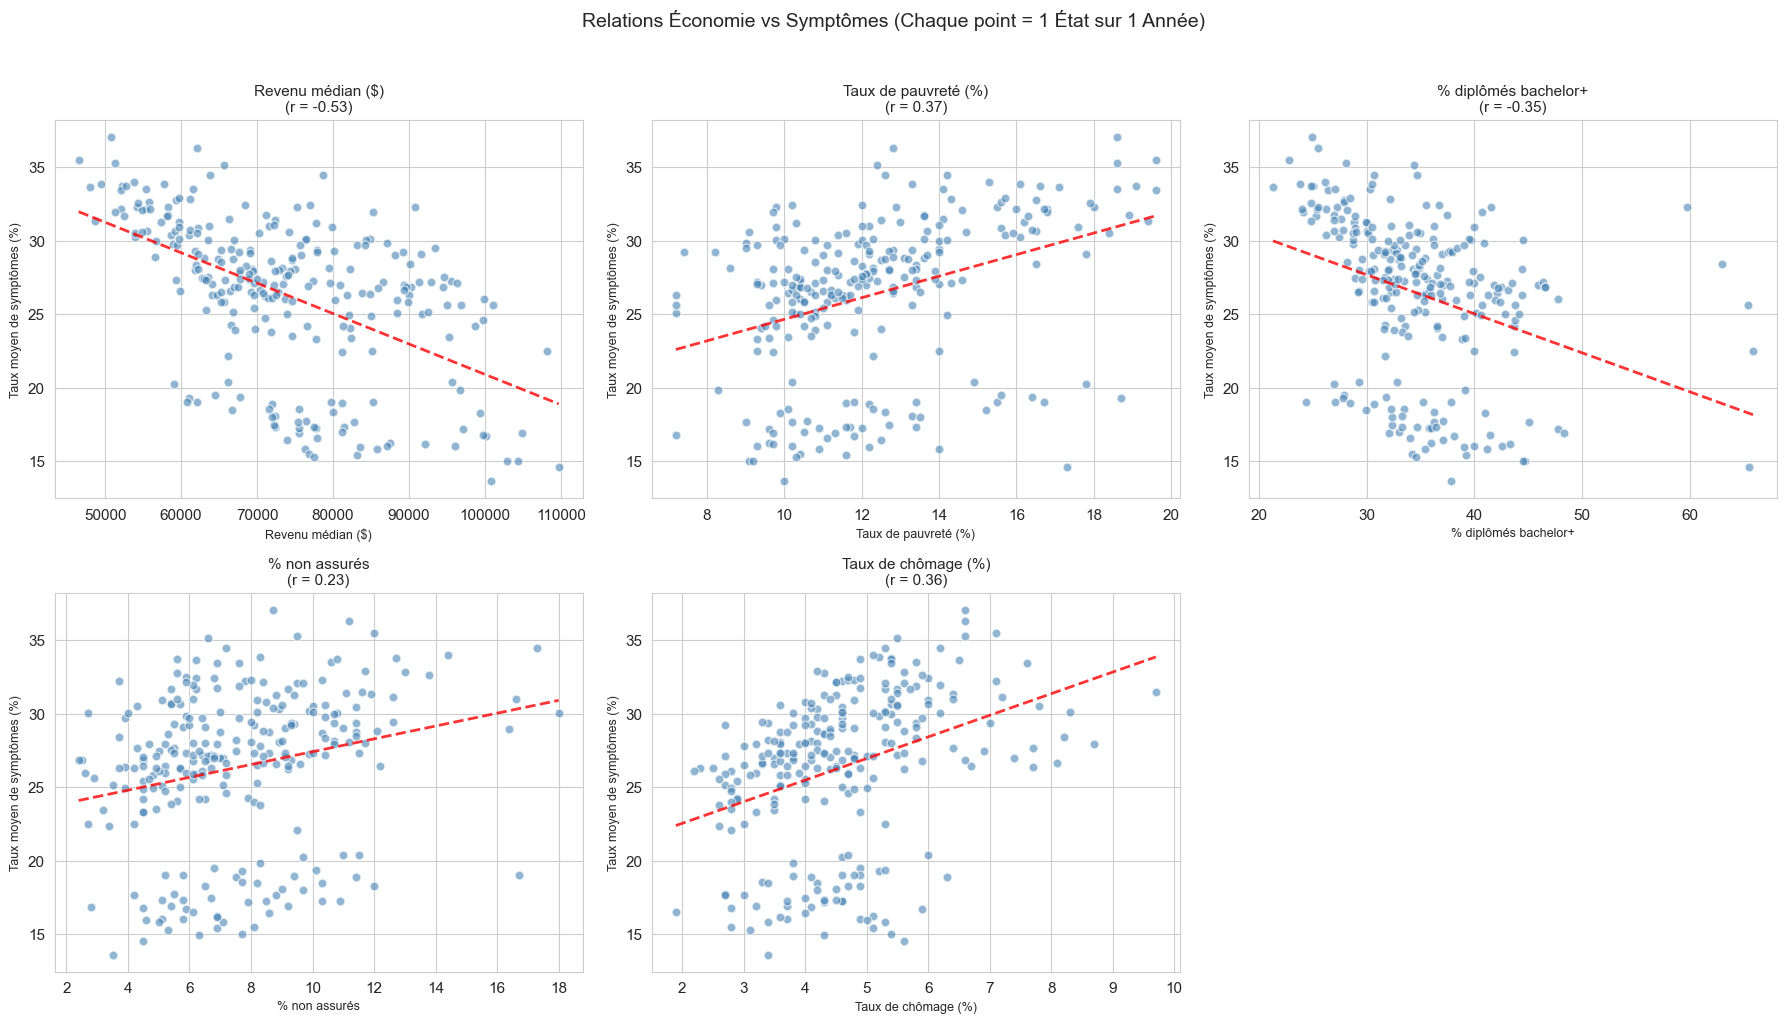

In [16]:
# === CELL 15: Key Scatter Plots ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plots = [
    ('median_household_income', 'Revenu médian ($)'),
    ('poverty_rate', 'Taux de pauvreté (%)'),
    ('pct_bachelors_or_higher', "% diplômés bachelor+"),
    ('pct_uninsured', '% non assurés'),
    ('unemployment_rate', 'Taux de chômage (%)'),
]

for i, (col, label) in enumerate(plots):
    ax = axes[i // 3][i % 3]
    # Points represent 1 State from 1 specific year
    ax.scatter(state_year_avg[col], state_year_avg['mean_value'], 
               alpha=0.6, s=40, color='steelblue', edgecolors='white')
    
    # We handle potential NaNs to avoid polyfit errors
    mask = ~np.isnan(state_year_avg[col]) & ~np.isnan(state_year_avg['mean_value'])
    z = np.polyfit(state_year_avg[col][mask], state_year_avg['mean_value'][mask], 1)
    p = np.poly1d(z)
    x_line = np.linspace(state_year_avg[col].min(), state_year_avg[col].max(), 100)
    ax.plot(x_line, p(x_line), '--', color='red', alpha=0.8, linewidth=2)
    
    # Correlation coefficient
    r = state_year_avg[col].corr(state_year_avg['mean_value'])
    ax.set_title(f'{label}\n(r = {r:.2f})', fontsize=11)
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Taux moyen de symptômes (%)', fontsize=9)
    
# we hide the empty 6th graph for a nice display
axes[1][2].set_visible(False)

plt.suptitle('Relations Économie vs Symptômes (Chaque point = 1 État sur 1 Année)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



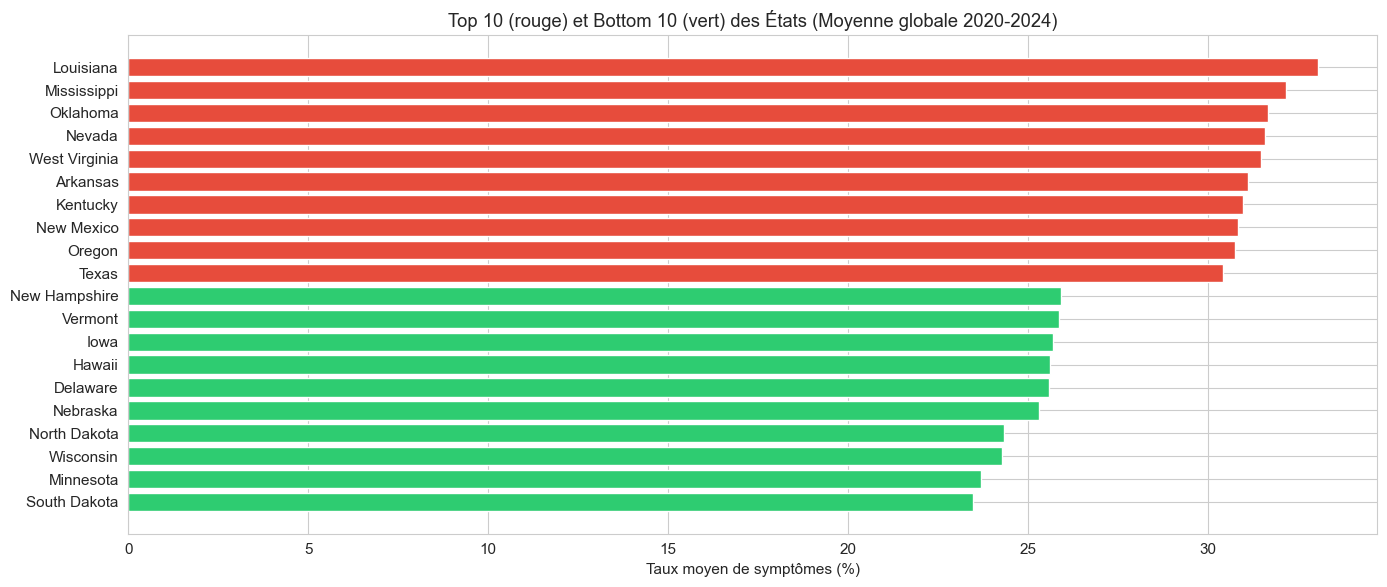

In [17]:
# === CELL 16: Top and Bottom States (Overall 2020-2024) ===
# We calculate a strict average per state over the entire period
state_overall_avg = df_state.groupby('Subgroup')['Value'].mean().reset_index()
state_avg_sorted = state_overall_avg.sort_values('Value', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))

# Top 10 and Bottom 10
top10 = state_avg_sorted.head(10)
bottom10 = state_avg_sorted.tail(10)
display_df = pd.concat([top10, bottom10])

colors = ['#e74c3c'] * 10 + ['#2ecc71'] * 10
ax.barh(range(len(display_df)), display_df['Value'], color=colors, edgecolor='white')
ax.set_yticks(range(len(display_df)))
ax.set_yticklabels(display_df['Subgroup'])
ax.set_xlabel('Taux moyen de symptômes (%)')
ax.set_title('Top 10 (rouge) et Bottom 10 (vert) des États (Moyenne globale 2020-2024)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [18]:
# === CELL 17: Socioeconomic Impact by Indicator Type (Panel Data) ===
print("Corrélation (Panel 2020-2024) poverty_rate & income vs Value par indicateur :")
print("=" * 70)

for indicator in df_state['Indicator'].unique():
    subset = df_state[df_state['Indicator'] == indicator]
    
    # Spatio-Temporal Aggregation
    state_year_means = subset.groupby(['Subgroup', 'Year']).agg(
        mean_value=('Value', 'mean'),
        poverty_rate=('poverty_rate', 'first'),
        median_household_income=('median_household_income', 'first')
    )
    
    r_pov = state_year_means['mean_value'].corr(state_year_means['poverty_rate'])
    r_inc = state_year_means['mean_value'].corr(state_year_means['median_household_income'])
    
    short_name = indicator.replace('Symptoms of ', '')
    print(f"  {short_name:45s} | r(poverty)={r_pov:+.2f} | r(income)={r_inc:+.2f}")

Corrélation (Panel 2020-2024) poverty_rate & income vs Value par indicateur :
  Depressive Disorder                           | r(poverty)=+0.42 | r(income)=-0.57
  Anxiety Disorder                              | r(poverty)=+0.33 | r(income)=-0.50
  Anxiety Disorder or Depressive Disorder       | r(poverty)=+0.35 | r(income)=-0.51


In [19]:
# === CELL 19: Data Preparation  ===
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# 1. Load and merge the 2 datasets
df_anxiety = pd.read_csv('Indicators_of_Anxiety_or_Depression.csv')
df_socio = pd.read_csv('master_socioeconomic_data_2020_2024.csv')

df_anxiety['Time Period Start Date'] = pd.to_datetime(df_anxiety['Time Period Start Date'])
df_anxiety['Year'] = df_anxiety['Time Period Start Date'].dt.year
df_anxiety = df_anxiety[df_anxiety['Group'] == 'By State'].copy()

# Merging
df_reg = pd.merge(df_anxiety, df_socio, on=['State', 'Year'], how='inner')
df_reg = df_reg.dropna(subset=['Value', 'median_household_income']).copy()

# 2. Delete the indicator
# Only keep depression. No need of 'Indicator_enc'
df_reg = df_reg[df_reg['Indicator'] == 'Symptoms of Depressive Disorder'].copy()

# 3. Defining the features (economic features, without 'Year')
num_features = ['median_household_income', 'poverty_rate', 'pct_bachelors_or_higher',
                'pct_uninsured', 'unemployment_rate']

X = df_reg[num_features].copy()
y = df_reg['Value'].copy()
groups = df_reg['State'].copy() # Keep the group to avoid data leakage

print(f"\nX : {X.shape[0]} échantillons, {X.shape[1]} features purement économiques")
print(f"Features : {list(X.columns)}")

# 4. Split without data leakage across states (group-based split)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy() 

print(f"\nTrain : {X_train.shape[0]} lignes (États différents de ceux du Test)")
print(f"Test  : {X_test.shape[0]} lignes (États jamais vus par le modèle)")

# 5. Standardisation
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])



X : 3519 échantillons, 5 features purement économiques
Features : ['median_household_income', 'poverty_rate', 'pct_bachelors_or_higher', 'pct_uninsured', 'unemployment_rate']

Train : 2760 lignes (États différents de ceux du Test)
Test  : 759 lignes (États jamais vus par le modèle)


In [20]:
# === CELL 20: Train and Evaluate 4 Regression Models ===
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
gkf = GroupKFold(n_splits=5) # K-Fold based on the groups

def evaluate(model, name, X_tr, y_tr, X_te, y_te):
    """Entraîne, cross-valide (GroupKFold) et évalue sur le test set."""
    # Cross-validation secured with "groups_train"
    cv = cross_val_score(model, X_tr, y_tr, groups=groups_train, cv=gkf, scoring='neg_mean_absolute_error')
    
    # Training
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    
    row = {
        'Modèle': name,
        'CV MAE (mean ± std)': f"{-cv.mean():.3f} ± {cv.std():.3f}",
        'Test MAE': round(mae, 3),
        'Test RMSE': round(rmse, 3),
        'Test R²': round(r2, 3)
    }
    results.append(row)
    return model

# 1. Linear Regression (baseline)
lr = evaluate(LinearRegression(), 'Régression linéaire',
              X_train_scaled, y_train, X_test_scaled, y_test)

# 2. Ridge
ridge = evaluate(Ridge(alpha=1.0), 'Ridge (α=1.0)',
                 X_train_scaled, y_train, X_test_scaled, y_test)

# 3. KNN
knn = evaluate(KNeighborsRegressor(n_neighbors=10), 'KNN (k=10)',
               X_train_scaled, y_train, X_test_scaled, y_test)

# 4. SGD
sgd = evaluate(SGDRegressor(loss='squared_error', penalty='l2', 
                             max_iter=1000, random_state=42),
               'SGD Regressor',
               X_train_scaled, y_train, X_test_scaled, y_test)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

             Modèle CV MAE (mean ± std)  Test MAE  Test RMSE  Test R²
Régression linéaire       3.274 ± 0.108     3.438      4.288    0.285
      Ridge (α=1.0)       3.274 ± 0.108     3.438      4.288    0.285
         KNN (k=10)       3.702 ± 0.244     3.837      4.787    0.109
      SGD Regressor       3.279 ± 0.108     3.440      4.290    0.285


In [21]:
# === CELL 20b: Additional Models - SVR, Random Forest, Gradient Boosting ===
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 5. SVR
evaluate(SVR(kernel='rbf', C=10), 'SVR (RBF, C=10)',
         X_train_scaled, y_train, X_test_scaled, y_test)

# 6. Random Forest
evaluate(RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
         'Random Forest',
         X_train_scaled, y_train, X_test_scaled, y_test)

# 7. Gradient Boosting
evaluate(GradientBoostingRegressor(n_estimators=200, max_depth=5, 
                                    learning_rate=0.1, random_state=42),
         'Gradient Boosting',
         X_train_scaled, y_train, X_test_scaled, y_test)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

             Modèle CV MAE (mean ± std)  Test MAE  Test RMSE  Test R²
Régression linéaire       3.274 ± 0.108     3.438      4.288    0.285
      Ridge (α=1.0)       3.274 ± 0.108     3.438      4.288    0.285
         KNN (k=10)       3.702 ± 0.244     3.837      4.787    0.109
      SGD Regressor       3.279 ± 0.108     3.440      4.290    0.285
    SVR (RBF, C=10)       4.019 ± 0.200     3.364      4.289    0.285
      Random Forest       3.465 ± 0.150     3.533      4.410    0.244
  Gradient Boosting       3.636 ± 0.237     3.652      4.589    0.182


In [22]:
# === CELL 21: Hyperparameter Tuning via Cross-Validation ===
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import GridSearchCV

# --- Ridge ---
print("Tuning Ridge (alpha)...")
ridge_grid = GridSearchCV(Ridge(), {'alpha': [0.01, 0.1, 1, 10, 100]},
                          cv=gkf, scoring='neg_mean_absolute_error')
ridge_grid.fit(X_train_scaled, y_train, groups=groups_train)
print(f"  Meilleur alpha : {ridge_grid.best_params_['alpha']}")
print(f"  CV MAE : {-ridge_grid.best_score_:.3f}")

# --- KNN ---
print("\nTuning KNN (k)...")
knn_grid = GridSearchCV(KNeighborsRegressor(), {'n_neighbors': [3, 5, 10, 15, 20, 30]},
                        cv=gkf, scoring='neg_mean_absolute_error')
knn_grid.fit(X_train_scaled, y_train, groups=groups_train)
print(f"  Meilleur k : {knn_grid.best_params_['n_neighbors']}")
print(f"  CV MAE : {-knn_grid.best_score_:.3f}")

# --- SGD ---
print("\nTuning SGD...")
sgd_grid = GridSearchCV(SGDRegressor(max_iter=1000, random_state=42),
                        {'alpha': [0.0001, 0.001, 0.01, 0.1], 'penalty': ['l2', 'l1', 'elasticnet']},
                        cv=gkf, scoring='neg_mean_absolute_error')
sgd_grid.fit(X_train_scaled, y_train, groups=groups_train)
print(f"  Meilleurs params : {sgd_grid.best_params_}")
print(f"  CV MAE : {-sgd_grid.best_score_:.3f}")

# --- Evaluation ---
print("\n" + "=" * 80)
print("RÉSULTATS APRÈS TUNING (évaluation sur le test set)")
print("=" * 80)

tuned_models = {'Ridge (tuned)': ridge_grid, 'KNN (tuned)': knn_grid, 'SGD (tuned)': sgd_grid}
tuned_results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    tuned_results.append({
        'Modèle': name,
        'Meilleurs params': str(model.best_params_),
        'Test MAE': round(mean_absolute_error(y_test, y_pred), 3),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
        'Test R²': round(r2_score(y_test, y_pred), 3)
    })

tuned_df = pd.DataFrame(tuned_results)
print(tuned_df.to_string(index=False))

Tuning Ridge (alpha)...
  Meilleur alpha : 100
  CV MAE : 3.259

Tuning KNN (k)...
  Meilleur k : 30
  CV MAE : 3.438

Tuning SGD...
  Meilleurs params : {'alpha': 0.1, 'penalty': 'l1'}
  CV MAE : 3.253

RÉSULTATS APRÈS TUNING (évaluation sur le test set)
       Modèle                Meilleurs params  Test MAE  Test RMSE  Test R²
Ridge (tuned)                  {'alpha': 100}     3.425      4.289    0.285
  KNN (tuned)             {'n_neighbors': 30}     3.338      4.208    0.312
  SGD (tuned) {'alpha': 0.1, 'penalty': 'l1'}     3.420      4.286    0.286


In [23]:
# === CELL 21b: Tuning SVR, Random Forest, Gradient Boosting ===
# --- SVR ---
print("Tuning SVR...")
svr_grid = GridSearchCV(SVR(kernel='rbf'), {'C': [1, 10, 100], 'gamma': ['scale', 'auto']},
                        cv=gkf, scoring='neg_mean_absolute_error')
svr_grid.fit(X_train_scaled, y_train, groups=groups_train)
print(f"  Meilleurs params : {svr_grid.best_params_}")

# --- Random Forest ---
print("\nTuning Random Forest...")
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42),
                       {'n_estimators': [100, 200], 'max_depth': [5, 10]}, 
                       cv=gkf, scoring='neg_mean_absolute_error', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train, groups=groups_train)
print(f"  Meilleurs params : {rf_grid.best_params_}")

# --- Gradient Boosting ---
print("\nTuning Gradient Boosting...")
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42),
                       {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]},
                       cv=gkf, scoring='neg_mean_absolute_error')
gb_grid.fit(X_train_scaled, y_train, groups=groups_train)
print(f"  Meilleurs params : {gb_grid.best_params_}")

# --- Tuned results ---
new_tuned = {'SVR (tuned)': svr_grid, 'Random Forest (tuned)': rf_grid, 'Gradient Boosting (tuned)': gb_grid}

print(f"\n{'='*80}")
print("NOUVEAUX MODÈLES APRÈS TUNING")
print(f"{'='*80}")
for name, model in new_tuned.items():
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"  {name:30s} | MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f}")
    tuned_models[name] = model

Tuning SVR...
  Meilleurs params : {'C': 1, 'gamma': 'auto'}

Tuning Random Forest...
  Meilleurs params : {'max_depth': 5, 'n_estimators': 100}

Tuning Gradient Boosting...
  Meilleurs params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

NOUVEAUX MODÈLES APRÈS TUNING
  SVR (tuned)                    | MAE: 3.317 | RMSE: 4.262 | R²: 0.294
  Random Forest (tuned)          | MAE: 3.506 | RMSE: 4.405 | R²: 0.246
  Gradient Boosting (tuned)      | MAE: 3.461 | RMSE: 4.371 | R²: 0.257


TABLEAU COMPARATIF FINAL — 7 MODÈLES
                   Modèle CV MAE (mean ± std)  Test MAE  Test RMSE  Test R²
              KNN (tuned)               3.438     3.338      4.208    0.312
              SVR (tuned)               3.364     3.317      4.262    0.294
              SGD (tuned)               3.253     3.420      4.286    0.286
      Régression linéaire       3.274 ± 0.108     3.438      4.288    0.285
            Ridge (α=1.0)       3.274 ± 0.108     3.438      4.288    0.285
            SGD Regressor       3.279 ± 0.108     3.440      4.290    0.285
          SVR (RBF, C=10)       4.019 ± 0.200     3.364      4.289    0.285
            Ridge (tuned)               3.259     3.425      4.289    0.285
Gradient Boosting (tuned)               3.380     3.461      4.371    0.257
    Random Forest (tuned)               3.350     3.506      4.405    0.246
            Random Forest       3.465 ± 0.150     3.533      4.410    0.244
        Gradient Boosting       3.636 ± 0.237     3

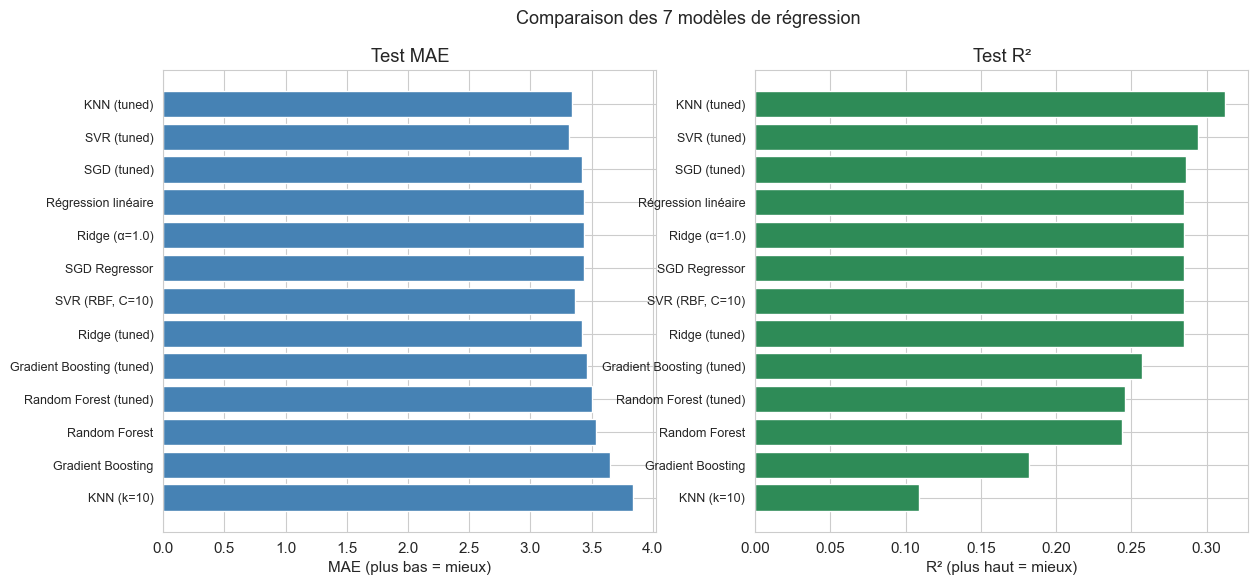

In [24]:
# === CELL 22: Final Comparison - All Models ===
all_results = results.copy()
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    cv_score = model.best_score_ if hasattr(model, 'best_score_') else None
    all_results.append({
        'Modèle': name,
        'CV MAE (mean ± std)': f"{-cv_score:.3f}" if cv_score else "—",
        'Test MAE': round(mean_absolute_error(y_test, y_pred), 3),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
        'Test R²': round(r2_score(y_test, y_pred), 3)
    })

final_df = pd.DataFrame(all_results).sort_values('Test R²', ascending=False)
print("TABLEAU COMPARATIF FINAL — 7 MODÈLES")
print("=" * 90)
print(final_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_names = final_df['Modèle']
x = range(len(models_names))

axes[0].barh(x, final_df['Test MAE'], color='steelblue', edgecolor='white')
axes[0].set_yticks(x)
axes[0].set_yticklabels(models_names, fontsize=9)
axes[0].set_xlabel('MAE (plus bas = mieux)')
axes[0].set_title('Test MAE')
axes[0].invert_yaxis()

axes[1].barh(x, final_df['Test R²'], color='seagreen', edgecolor='white')
axes[1].set_yticks(x)
axes[1].set_yticklabels(models_names, fontsize=9)
axes[1].set_xlabel('R² (plus haut = mieux)')
axes[1].set_title('Test R²')
axes[1].invert_yaxis()

plt.suptitle('Comparaison des 7 modèles de régression', fontsize=13)
plt.show()

Meilleur modèle : KNN (tuned)


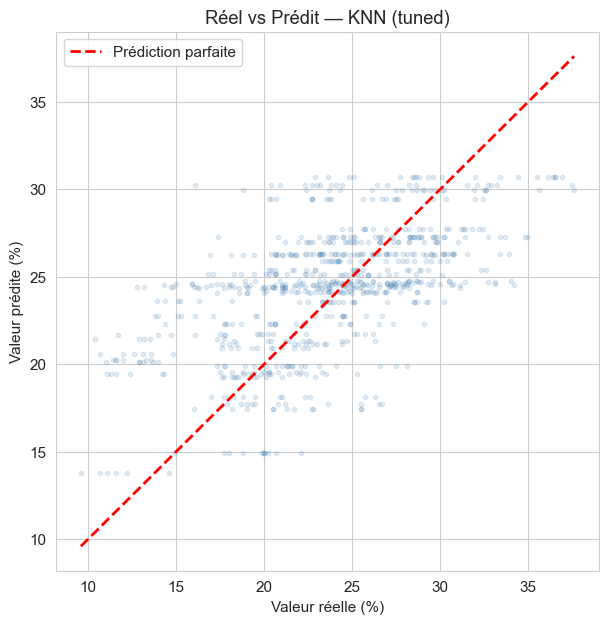

R² = 0.312, MAE = 3.338


In [25]:
# === CELL 23: True vs Predicted (best model) ===
best_name = final_df.iloc[0]['Modèle']
print(f"Meilleur modèle : {best_name}")

# Find the best model
all_models = {
    'Ridge (tuned)': ridge_grid, 'KNN (tuned)': knn_grid, 'SGD (tuned)': sgd_grid,
    'SVR (tuned)': svr_grid, 'Random Forest (tuned)': rf_grid, 
    'Gradient Boosting (tuned)': gb_grid
}
best_model = all_models.get(best_name, knn_grid)

y_pred_best = best_model.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_best, alpha=0.15, s=10, color='steelblue')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
        'r--', linewidth=2, label='Prédiction parfaite')
ax.set_xlabel('Valeur réelle (%)')
ax.set_ylabel('Valeur prédite (%)')
ax.set_title(f'Réel vs Prédit — {best_name}')
ax.legend()
plt.show()

print(f"R² = {r2_score(y_test, y_pred_best):.3f}, MAE = {mean_absolute_error(y_test, y_pred_best):.3f}")

In [26]:
# === Feature Importance via Ridge coefficients ===
ridge_best = ridge_grid.best_estimator_
coefs = pd.Series(np.abs(ridge_best.coef_), index=num_features)
coefs_pct = (coefs / coefs.sum() * 100).sort_values(ascending=False)

print("POIDS DES VARIABLES (Ridge, valeurs absolues normalisées) :")
for col, val in coefs_pct.items():
    print(f"  {col:35s} : {val:.1f} %")

POIDS DES VARIABLES (Ridge, valeurs absolues normalisées) :
  median_household_income             : 43.3 %
  unemployment_rate                   : 41.1 %
  pct_uninsured                       : 9.4 %
  poverty_rate                        : 3.6 %
  pct_bachelors_or_higher             : 2.6 %


In [27]:
# === CELL: Overfitting Check - Regression ===
print("VÉRIFICATION OVERFITTING — RÉGRESSION")
print("=" * 75)
print(f"{'Modèle':30s} {'Train R²':>10s} {'Test R²':>10s} {'Écart':>10s}")
print("-" * 75)

models_to_check = {
    'Régression linéaire': lr,
    'KNN (tuned)': knn_grid,
    'SVR (tuned)': svr_grid,
    'Random Forest (tuned)': rf_grid,
    'Gradient Boosting (tuned)': gb_grid,
    'Ridge':ridge_grid

}

for name, model in models_to_check.items():
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    ecart = train_r2 - test_r2
    flag = " /!\ " if ecart > 0.10 else " OK "
    print(f"{name:30s} {train_r2:10.3f} {test_r2:10.3f} {ecart:10.3f}{flag}")

VÉRIFICATION OVERFITTING — RÉGRESSION
Modèle                           Train R²    Test R²      Écart
---------------------------------------------------------------------------
Régression linéaire                 0.300      0.285      0.015 OK 
KNN (tuned)                         0.444      0.312      0.133 /!\ 
SVR (tuned)                         0.362      0.294      0.068 OK 
Random Forest (tuned)               0.450      0.246      0.204 /!\ 
Gradient Boosting (tuned)           0.482      0.257      0.225 /!\ 
Ridge                               0.299      0.285      0.014 OK 


In [28]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor

print(">>> Test du Bagging avec KNN...")
# On utilise le KNN comme estimateur de base
base_knn = KNeighborsRegressor(n_neighbors=30, weights='uniform')

bagging_knn = BaggingRegressor(
    estimator=base_knn, 
    n_estimators=50, 
    max_samples=0.8, 
    random_state=42, 
    n_jobs=-1
)

bagging_knn.fit(X_train_scaled, y_train)
y_pred_bag_knn = bagging_knn.predict(X_test_scaled)

print(f"R² (Bagging KNN) sur le Test Set : {r2_score(y_test, y_pred_bag_knn):.3f}")

>>> Test du Bagging avec KNN...
R² (Bagging KNN) sur le Test Set : 0.317


In [29]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("\n>>> Test du Bagging avec Arbre de décision (Tâche 1 - Régression)...")
# On utilise un Arbre de décision comme estimateur de base
# on a mis max_depth=10 pour être comparable au Random Forest initial
base_tree_reg = DecisionTreeRegressor(max_depth=10, random_state=42)

bagging_tree_reg = BaggingRegressor(
    estimator=base_tree_reg, 
    n_estimators=100, 
    max_samples=0.8, 
    random_state=42, 
    n_jobs=-1
)
bagging_tree_reg.fit(X_train_scaled, y_train)
y_pred_bag_tree = bagging_tree_reg.predict(X_test_scaled)

# On évalue avec les 3 métriques de ton projet
mae_bag_tree = mean_absolute_error(y_test, y_pred_bag_tree)
rmse_bag_tree = np.sqrt(mean_squared_error(y_test, y_pred_bag_tree))
r2_bag_tree = r2_score(y_test, y_pred_bag_tree)

print(f"R²   (Bagging Tree) : {r2_bag_tree:.3f}")


>>> Test du Bagging avec Arbre de décision (Tâche 1 - Régression)...
R²   (Bagging Tree) : 0.234


In [30]:
# === CELL 24-clf: Classification - Predict Critical State ===
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# We reuse the same clean dataset as Task 1:
# - Only "Symptoms of Depressive Disorder"
# - Purely socio-economic features
# - Split using GroupShuffleSplit (no data leakage)

# df_reg is already filtered on the depression from Task 1
print(f"Dataset : {df_reg.shape[0]} échantillons (dépression uniquement)")

# Testing multiple thresholds
print("\nDistribution de Value (dépression) :")
print(f"  Moyenne : {df_reg['Value'].mean():.1f}%")
print(f"  Médiane : {df_reg['Value'].median():.1f}%")
for seuil in [18, 20, 22, 25]:
    n_pos = (df_reg['Value'] >= seuil).sum()
    pct = n_pos / len(df_reg) * 100
    print(f"  Seuil {seuil}% : {n_pos} positifs ({pct:.1f}%)")

# Choose a threshold close to the median to balance the classes
SEUIL = 22  

# Binary target
df_clf2 = df_reg.copy()
df_clf2['is_critical'] = (df_clf2['Value'] >= SEUIL).astype(int)
print(f"\nSeuil retenu : {SEUIL}%")
print(f"Classe 0 (< {SEUIL}%) : {(df_clf2['is_critical'] == 0).sum()}")
print(f"Classe 1 (≥ {SEUIL}%) : {(df_clf2['is_critical'] == 1).sum()}")

# Features: ONLY socio-economic (no Year, no Indicator_enc)
num_features_clf = ['median_household_income', 'poverty_rate', 'pct_bachelors_or_higher',
                    'pct_uninsured', 'unemployment_rate']

X_clf = df_clf2[num_features_clf].copy()
y_clf = df_clf2['is_critical'].copy()
groups_clf = df_clf2['State'].copy()

print(f"\nX : {X_clf.shape[0]} échantillons, {X_clf.shape[1]} features")
print(f"Features : {list(X_clf.columns)}")
print(f"(Pas de Year, pas d'Indicator_enc, pas de Value)")

# Split without data leakage across states (group-based split)
gss_clf = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss_clf.split(X_clf, y_clf, groups_clf))

X_train_clf = X_clf.iloc[train_idx].copy()
X_test_clf = X_clf.iloc[test_idx].copy()
y_train_clf = y_clf.iloc[train_idx].copy()
y_test_clf = y_clf.iloc[test_idx].copy()
groups_train_clf = groups_clf.iloc[train_idx].copy()

print(f"\nTrain : {X_train_clf.shape[0]} (États différents du Test)")
print(f"Test  : {X_test_clf.shape[0]} (États jamais vus)")

# Standardisation
scaler_clf = StandardScaler()
X_train_clf_sc = X_train_clf.copy()
X_test_clf_sc = X_test_clf.copy()
X_train_clf_sc[num_features_clf] = scaler_clf.fit_transform(X_train_clf[num_features_clf])
X_test_clf_sc[num_features_clf] = scaler_clf.transform(X_test_clf[num_features_clf])

Dataset : 3519 échantillons (dépression uniquement)

Distribution de Value (dépression) :
  Moyenne : 22.6%
  Médiane : 22.6%
  Seuil 18% : 2950 positifs (83.8%)
  Seuil 20% : 2570 positifs (73.0%)
  Seuil 22% : 1943 positifs (55.2%)
  Seuil 25% : 1096 positifs (31.1%)

Seuil retenu : 22%
Classe 0 (< 22%) : 1576
Classe 1 (≥ 22%) : 1943

X : 3519 échantillons, 5 features
Features : ['median_household_income', 'poverty_rate', 'pct_bachelors_or_higher', 'pct_uninsured', 'unemployment_rate']
(Pas de Year, pas d'Indicator_enc, pas de Value)

Train : 2760 (États différents du Test)
Test  : 759 (États jamais vus)


In [31]:
# === CELL 25-clf: Train 6 Classifiers ===
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.metrics import accuracy_score

results_clf2 = []
gkf_clf = GroupKFold(n_splits=5)

def eval_clf2(model, name, X_tr, y_tr, X_te, y_te):
    cv = cross_val_score(model, X_tr, y_tr, groups=groups_train_clf, 
                         cv=gkf_clf, scoring='accuracy')
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    results_clf2.append({
        'Modèle': name,
        'CV Accuracy': f"{cv.mean():.3f} ± {cv.std():.3f}",
        'Test Accuracy': round(acc, 3)
    })
    print(f"{name:30s} | CV: {cv.mean():.3f} ± {cv.std():.3f} | Test: {acc:.3f}")
    return model

print(f"{'Modèle':30s} | {'CV Accuracy':20s} | {'Test Acc':8s}")
print("=" * 70)

lr2 = eval_clf2(LogisticRegression(max_iter=1000, random_state=42),
                'Régression logistique', X_train_clf_sc, y_train_clf, X_test_clf_sc, y_test_clf)

knn2 = eval_clf2(KNeighborsClassifier(n_neighbors=10),
                 'KNN (k=10)', X_train_clf_sc, y_train_clf, X_test_clf_sc, y_test_clf)

nb2 = eval_clf2(GaussianNB(),
                'Naive Bayes', X_train_clf_sc, y_train_clf, X_test_clf_sc, y_test_clf)

svm2 = eval_clf2(SVC(kernel='rbf', C=10, probability=True, random_state=42),
                 'SVM (RBF, C=10)', X_train_clf_sc, y_train_clf, X_test_clf_sc, y_test_clf)

rf2 = eval_clf2(RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
                'Random Forest', X_train_clf_sc, y_train_clf, X_test_clf_sc, y_test_clf)

gb2 = eval_clf2(GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                            learning_rate=0.1, random_state=42),
                'Gradient Boosting', X_train_clf_sc, y_train_clf, X_test_clf_sc, y_test_clf)

Modèle                         | CV Accuracy          | Test Acc
Régression logistique          | CV: 0.688 ± 0.026 | Test: 0.738
KNN (k=10)                     | CV: 0.639 ± 0.042 | Test: 0.731
Naive Bayes                    | CV: 0.663 ± 0.038 | Test: 0.721
SVM (RBF, C=10)                | CV: 0.606 ± 0.061 | Test: 0.758
Random Forest                  | CV: 0.677 ± 0.033 | Test: 0.776
Gradient Boosting              | CV: 0.625 ± 0.024 | Test: 0.660


In [32]:
# === CELL 26-clf: Hyperparameter Tuning ===
from sklearn.model_selection import GridSearchCV

tuned_clfs2 = {}

print("Tuning Régression Logistique...")
lr2_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100]},
    cv=gkf_clf, scoring='accuracy'
)
lr2_grid.fit(X_train_clf_sc, y_train_clf, groups=groups_train_clf)
tuned_clfs2['Logistique (tuned)'] = lr2_grid
print(f"  Meilleur C : {lr2_grid.best_params_['C']} | CV Acc : {lr2_grid.best_score_:.3f}")

print("Tuning KNN...")
knn2_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 10, 15, 20, 30]},
    cv=gkf_clf, scoring='accuracy'
)
knn2_grid.fit(X_train_clf_sc, y_train_clf, groups=groups_train_clf)
tuned_clfs2['KNN (tuned)'] = knn2_grid
print(f"  Meilleur k : {knn2_grid.best_params_['n_neighbors']} | CV Acc : {knn2_grid.best_score_:.3f}")

print("Tuning SVM...")
svm2_grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    {'C': [1, 10, 100], 'gamma': ['scale', 'auto']},
    cv=gkf_clf, scoring='accuracy'
)
svm2_grid.fit(X_train_clf_sc, y_train_clf, groups=groups_train_clf)
tuned_clfs2['SVM (tuned)'] = svm2_grid
print(f"  Meilleurs params : {svm2_grid.best_params_} | CV Acc : {svm2_grid.best_score_:.3f}")

print("Tuning Random Forest...")
rf2_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [100, 200], 'max_depth': [5, 10, 15]},
    cv=gkf_clf, scoring='accuracy', n_jobs=-1
)
rf2_grid.fit(X_train_clf_sc, y_train_clf, groups=groups_train_clf)
tuned_clfs2['Random Forest (tuned)'] = rf2_grid
print(f"  Meilleurs params : {rf2_grid.best_params_} | CV Acc : {rf2_grid.best_score_:.3f}")

print("Tuning Gradient Boosting...")
gb2_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1, 0.2]},
    cv=gkf_clf, scoring='accuracy'
)
gb2_grid.fit(X_train_clf_sc, y_train_clf, groups=groups_train_clf)
tuned_clfs2['Gradient Boosting (tuned)'] = gb2_grid
print(f"  Meilleurs params : {gb2_grid.best_params_} | CV Acc : {gb2_grid.best_score_:.3f}")

# Tuned results
print(f"\n{'='*70}")
for name, model in tuned_clfs2.items():
    y_pred = model.predict(X_test_clf_sc)
    acc = accuracy_score(y_test_clf, y_pred)
    results_clf2.append({
        'Modèle': name,
        'CV Accuracy': f"{model.best_score_:.3f}",
        'Test Accuracy': round(acc, 3)
    })
    print(f"  {name:30s} | Test Accuracy : {acc:.3f}")

Tuning Régression Logistique...
  Meilleur C : 1 | CV Acc : 0.688
Tuning KNN...
  Meilleur k : 20 | CV Acc : 0.655
Tuning SVM...
  Meilleurs params : {'C': 1, 'gamma': 'scale'} | CV Acc : 0.658
Tuning Random Forest...
  Meilleurs params : {'max_depth': 5, 'n_estimators': 200} | CV Acc : 0.680
Tuning Gradient Boosting...
  Meilleurs params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100} | CV Acc : 0.671

  Logistique (tuned)             | Test Accuracy : 0.738
  KNN (tuned)                    | Test Accuracy : 0.773
  SVM (tuned)                    | Test Accuracy : 0.739
  Random Forest (tuned)          | Test Accuracy : 0.760
  Gradient Boosting (tuned)      | Test Accuracy : 0.711


TABLEAU COMPARATIF — CLASSIFICATION BINAIRE (SANS TRICHE)
                   Modèle   CV Accuracy  Test Accuracy
    Régression logistique 0.688 ± 0.026          0.738
               KNN (k=10) 0.639 ± 0.042          0.731
              Naive Bayes 0.663 ± 0.038          0.721
          SVM (RBF, C=10) 0.606 ± 0.061          0.758
            Random Forest 0.677 ± 0.033          0.776
        Gradient Boosting 0.625 ± 0.024          0.660
       Logistique (tuned)         0.688          0.738
              KNN (tuned)         0.655          0.773
              SVM (tuned)         0.658          0.739
    Random Forest (tuned)         0.680          0.760
Gradient Boosting (tuned)         0.671          0.711

Meilleur modèle : Random Forest


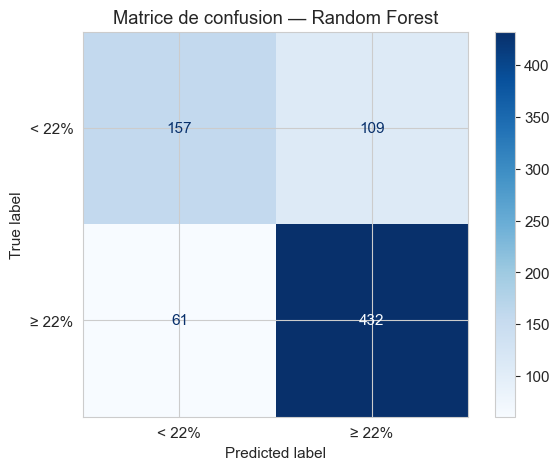

In [33]:
# === CELL 27-clf: Comparison + Confusion Matrix ===
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clf2_df = pd.DataFrame(results_clf2).drop_duplicates(subset='Modèle', keep='last')
print("TABLEAU COMPARATIF — CLASSIFICATION BINAIRE (SANS TRICHE)")
print("=" * 65)
print(clf2_df.to_string(index=False))

# Dictionary of ALL models (tuned and untuned)
all_clf2_models = {
    'Régression logistique': lr2,
    'KNN (k=10)': knn2,
    'Naive Bayes': nb2,
    'SVM (RBF, C=10)': svm2,
    'Random Forest': rf2,
    'Gradient Boosting': gb2,
    'Logistique (tuned)': lr2_grid,
    'KNN (tuned)': knn2_grid,
    'SVM (tuned)': svm2_grid,
    'Random Forest (tuned)': rf2_grid,
    'Gradient Boosting (tuned)': gb2_grid
}

# Find the real best model
best_name2 = clf2_df.sort_values('Test Accuracy', ascending=False).iloc[0]['Modèle']
print(f"\nMeilleur modèle : {best_name2}")

best_clf2 = all_clf2_models[best_name2]
y_pred_best2 = best_clf2.predict(X_test_clf_sc)

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test_clf, y_pred_best2)
disp = ConfusionMatrixDisplay(cm, display_labels=[f'< {SEUIL}%', f'≥ {SEUIL}%'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Matrice de confusion — {best_name2}')
plt.show()

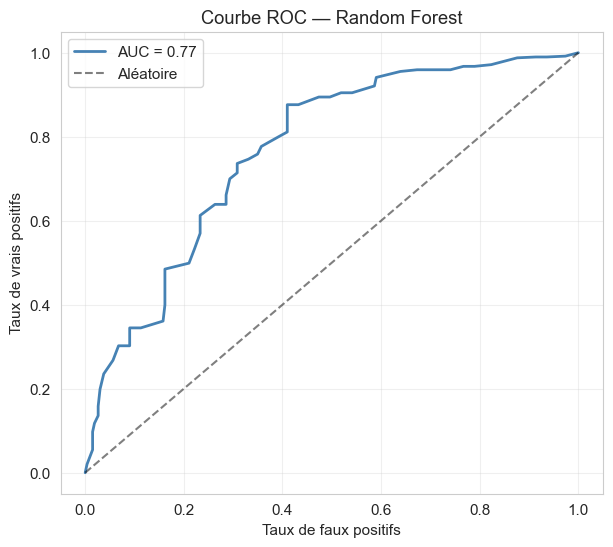

PRECISION / RECALL
Classe  Precision  Recall  F1-Score  Support
 < 22%      0.720   0.590     0.649      266
 ≥ 22%      0.799   0.876     0.836      493

Accuracy globale : 0.776
AUC : 0.768


In [34]:
# === CELL 28-clf: ROC + Precision/Recall ===
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support

# ROC
y_scores2 = best_clf2.predict_proba(X_test_clf_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_test_clf, y_scores2)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {roc_auc:.2f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aléatoire')
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title(f'Courbe ROC — {best_name2}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Precision / Recall
precision, recall, f1, support = precision_recall_fscore_support(y_test_clf, y_pred_best2)
pr_df = pd.DataFrame({
    'Classe': [f'< {SEUIL}%', f'≥ {SEUIL}%'],
    'Precision': precision.round(3),
    'Recall': recall.round(3),
    'F1-Score': f1.round(3),
    'Support': support
})
print("PRECISION / RECALL")
print("=" * 60)
print(pr_df.to_string(index=False))
print(f"\nAccuracy globale : {accuracy_score(y_test_clf, y_pred_best2):.3f}")
print(f"AUC : {roc_auc:.3f}")

In [35]:
# === CELL 29-clf: Overfitting Check ===
print("VÉRIFICATION OVERFITTING — CLASSIFICATION BINAIRE")
print("=" * 75)
print(f"{'Modèle':30s} {'Train Acc':>10s} {'Test Acc':>10s} {'Écart':>10s}")
print("-" * 75)

for name, model in tuned_clfs2.items():
    train_acc = accuracy_score(y_train_clf, model.predict(X_train_clf_sc))
    test_acc = accuracy_score(y_test_clf, model.predict(X_test_clf_sc))
    ecart = train_acc - test_acc
    flag = " /!\ " if ecart > 0.10 else " OK "
    print(f"{name:30s} {train_acc:10.3f} {test_acc:10.3f} {ecart:10.3f}{flag}")

VÉRIFICATION OVERFITTING — CLASSIFICATION BINAIRE
Modèle                          Train Acc   Test Acc      Écart
---------------------------------------------------------------------------
Logistique (tuned)                  0.678      0.738     -0.060 OK 
KNN (tuned)                         0.757      0.773     -0.017 OK 
SVM (tuned)                         0.717      0.739     -0.022 OK 
Random Forest (tuned)               0.758      0.760     -0.002 OK 
Gradient Boosting (tuned)           0.762      0.711      0.050 OK 


In [36]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

print("\n>>> Test du Bagging pour la Classification (Tâche 2)...")
# On utilise un Arbre de décision simple comme estimateur de base
base_tree = DecisionTreeClassifier(max_depth=5, random_state=42)

bagging_clf = BaggingClassifier(
    estimator=base_tree, 
    n_estimators=100, 
    max_samples=0.8, 
    random_state=42, 
    n_jobs=-1
)

bagging_clf.fit(X_train_clf_sc, y_train_clf)
y_pred_bag_clf = bagging_clf.predict(X_test_clf_sc)

acc_bagging = accuracy_score(y_test_clf, y_pred_bag_clf)
print(f"Accuracy (Bagging Tree) sur le Test Set : {acc_bagging:.3f}")


>>> Test du Bagging pour la Classification (Tâche 2)...
Accuracy (Bagging Tree) sur le Test Set : 0.744


In [37]:
print("\n>>> Test du Bagging avec KNN (Tâche 2)...")

# On utilise le meilleur KNN trouve lors du GridSearch (k=20)
base_knn_clf = KNeighborsClassifier(n_neighbors=20)

bagging_knn_clf = BaggingClassifier(
    estimator=base_knn_clf, 
    n_estimators=100, 
    max_samples=0.8, 
    random_state=42, 
    n_jobs=-1
)
bagging_knn_clf.fit(X_train_clf_sc, y_train_clf)
y_pred_bag_knn_clf = bagging_knn_clf.predict(X_test_clf_sc)

acc_bagging_knn = accuracy_score(y_test_clf, y_pred_bag_knn_clf)
print(f"Accuracy (Bagging KNN) sur le Test Set : {acc_bagging_knn:.3f}")


>>> Test du Bagging avec KNN (Tâche 2)...
Accuracy (Bagging KNN) sur le Test Set : 0.760


In [38]:
# === CELL 30: Prepare State-Level Data for Unsupervised Learning ===
from sklearn.preprocessing import StandardScaler

# We use the same dataset as Tasks 1 and 2 (2020-2024 data)
# df_reg is already filtered for depression from Task 1
# But for clustering, we want ALL indicators, not just depression

# Reload the complete data with socio-economic dynamics
df_all = pd.merge(
    df_anxiety[df_anxiety['Group'] == 'By State'],
    df_socio, 
    on=['State', 'Year'], 
    how='inner'
).dropna(subset=['Value', 'median_household_income'])

# Calculate the average profile of each state
state_profile = df_all.groupby('State').agg(
    mean_value=('Value', 'mean'),
    std_value=('Value', 'std'),
    median_household_income=('median_household_income', 'mean'),
    poverty_rate=('poverty_rate', 'mean'),
    pct_bachelors_or_higher=('pct_bachelors_or_higher', 'mean'),
    pct_uninsured=('pct_uninsured', 'mean'),
    unemployment_rate=('unemployment_rate', 'mean')
).reset_index()

print(f"Profils d'États : {state_profile.shape}")
print(state_profile.head())

# Features for unsupervised analysis
unsup_features = ['mean_value', 'median_household_income', 'poverty_rate',
                  'pct_bachelors_or_higher', 'pct_uninsured', 'unemployment_rate']

X_unsup = state_profile[unsup_features].copy()

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsup)

print(f"\nFeatures utilisées : {unsup_features}")
print(f"Shape : {X_scaled.shape}")

Profils d'États : (51, 8)
        State  mean_value  std_value  median_household_income  poverty_rate  \
0     Alabama   30.039130   6.441255             56691.231884     15.927536   
1      Alaska   28.731401   6.206787             82416.695652     10.476812   
2     Arizona   29.135266   6.838076             70041.420290     12.988406   
3    Arkansas   31.105797   6.805364             53878.594203     16.153623   
4  California   29.657488   7.152380             87086.057971     12.284058   

   pct_bachelors_or_higher  pct_uninsured  unemployment_rate  
0                27.714493       9.231884           4.928986  
1                31.501449      11.507246           6.240580  
2                32.231884      10.443478           5.217391  
3                25.159420       8.768116           4.894203  
4                36.243478       6.789855           6.527536  

Features utilisées : ['mean_value', 'median_household_income', 'poverty_rate', 'pct_bachelors_or_higher', 'pct_uninsured

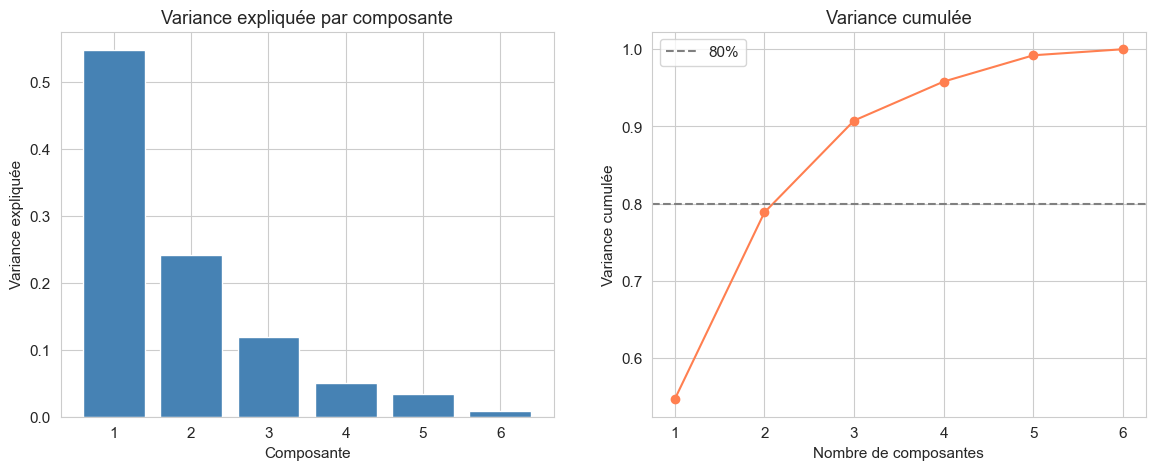

  PC1 : 0.547 (0.547 cumulée)
  PC2 : 0.242 (0.789 cumulée)
  PC3 : 0.119 (0.908 cumulée)
  PC4 : 0.050 (0.958 cumulée)
  PC5 : 0.034 (0.992 cumulée)
  PC6 : 0.008 (1.000 cumulée)


In [39]:
# === CELL 31: PCA ===
from sklearn.decomposition import PCA

# PCA with all components to see the variance explained
pca_full = PCA()
pca_full.fit(X_scaled)

# Variance explained
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(var_exp)+1), var_exp, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Composante')
axes[0].set_ylabel('Variance expliquée')
axes[0].set_title('Variance expliquée par composante')
axes[0].set_xticks(range(1, len(var_exp)+1))

# Cumulative variance
axes[1].plot(range(1, len(var_cum)+1), var_cum, 'o-', color='coral')
axes[1].axhline(y=0.80, color='gray', linestyle='--', label='80%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée')
axes[1].set_title('Variance cumulée')
axes[1].set_xticks(range(1, len(var_cum)+1))
axes[1].legend()


plt.show()

for i, (v, c) in enumerate(zip(var_exp, var_cum)):
    print(f"  PC{i+1} : {v:.3f} ({c:.3f} cumulée)")

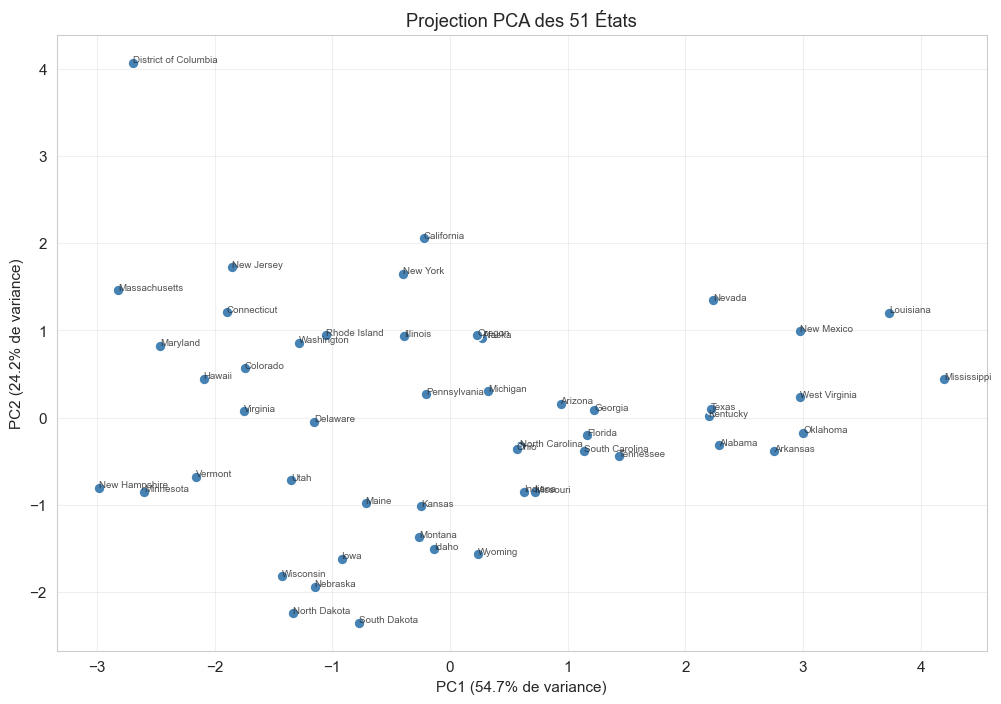

Contribution des features aux composantes principales :
                           PC1    PC2
mean_value               0.459  0.331
median_household_income -0.461  0.365
poverty_rate             0.478  0.189
pct_bachelors_or_higher -0.430  0.397
pct_uninsured            0.350 -0.149
unemployment_rate        0.202  0.736


In [40]:
# === CELL 32: PCA 2D Projection ===
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=60, color='steelblue', edgecolors='white')

for i, state in enumerate(state_profile['State']):
    ax.annotate(state, (X_pca[i, 0], X_pca[i, 1]), fontsize=7, alpha=0.8)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} de variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} de variance)')
ax.set_title('Projection PCA des 51 États')
ax.grid(True, alpha=0.3)
plt.show()

print("Contribution des features aux composantes principales :")
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=unsup_features,
    columns=['PC1', 'PC2']
).round(3)
print(loadings)

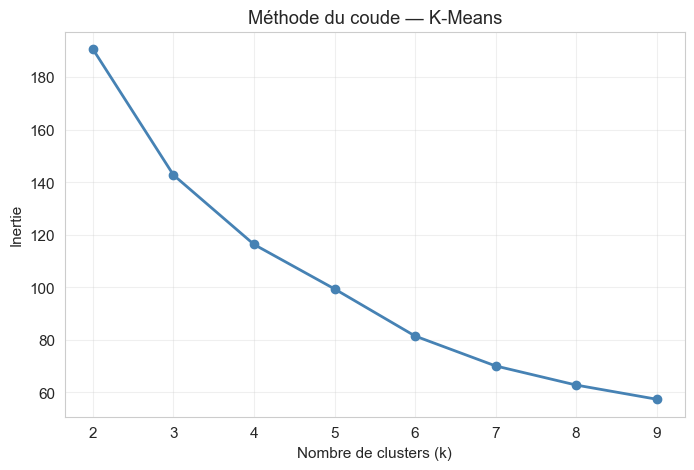

In [41]:
# === CELL 33: Elbow Method ===
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2)
ax.set_xlabel('Nombre de clusters (k)')
ax.set_ylabel('Inertie')
ax.set_title('Méthode du coude — K-Means')
ax.grid(True, alpha=0.3)
plt.show()


K-Means (k=3) — Silhouette score : 0.283

Profil moyen par cluster :
                mean_value  median_household_income  poverty_rate  pct_bachelors_or_higher  pct_uninsured  unemployment_rate
cluster_kmeans                                                                                                              
0                    27.58                 84670.15         11.14                    40.91           6.00               5.56
1                    26.39                 69400.77         11.24                    33.82           7.07               3.92
2                    30.51                 60209.79         15.46                    28.82          10.25               5.42


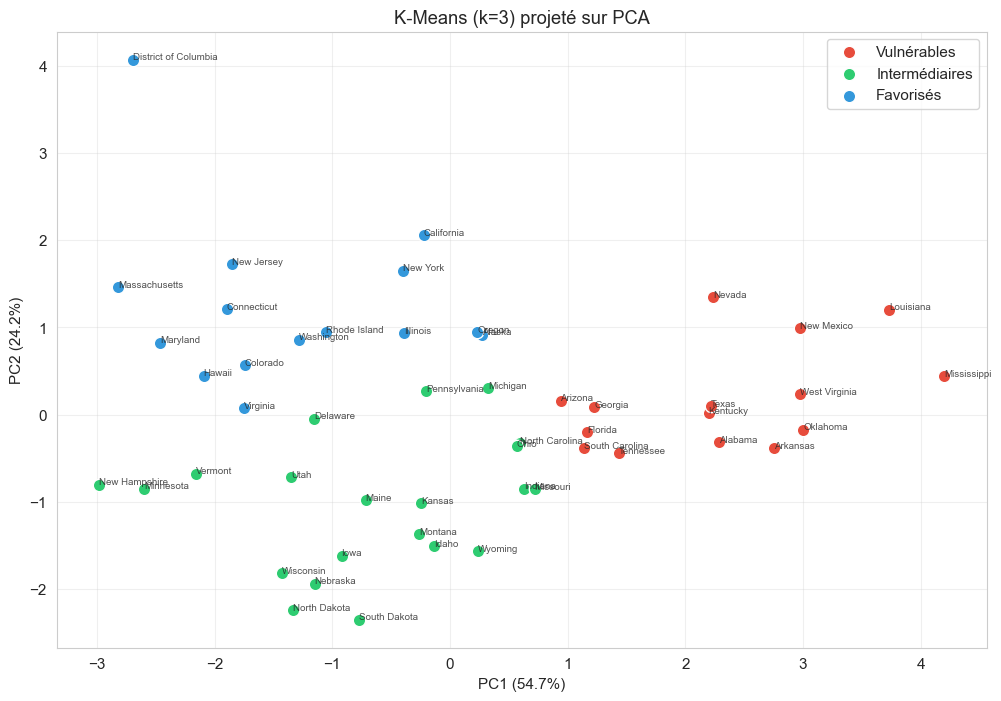


Vulnérables (15 États) : Alabama, Arizona, Arkansas, Florida, Georgia, Kentucky, Louisiana, Mississippi, Nevada, New Mexico, Oklahoma, South Carolina, Tennessee, Texas, West Virginia

Intermédiaires (21 États) : Delaware, Idaho, Indiana, Iowa, Kansas, Maine, Michigan, Minnesota, Missouri, Montana, Nebraska, New Hampshire, North Carolina, North Dakota, Ohio, Pennsylvania, South Dakota, Utah, Vermont, Wisconsin, Wyoming

Favorisés (15 États) : Alaska, California, Colorado, Connecticut, District of Columbia, Hawaii, Illinois, Maryland, Massachusetts, New Jersey, New York, Oregon, Rhode Island, Virginia, Washington


In [42]:
# === CELL 34: K-Means Clustering ===
from sklearn.metrics import silhouette_score

k_opt = 3
km = KMeans(n_clusters=k_opt, n_init=10, random_state=42)
state_profile['cluster_kmeans'] = km.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, state_profile['cluster_kmeans'])
print(f"K-Means (k={k_opt}) — Silhouette score : {sil:.3f}")

# Average profile per cluster
cluster_means = state_profile.groupby('cluster_kmeans')[unsup_features].mean().round(2)
print("\nProfil moyen par cluster :")
print(cluster_means.to_string())

# Rename according to income
names = {cluster_means['median_household_income'].idxmin(): 'Vulnérables',
         cluster_means['median_household_income'].idxmax(): 'Favorisés'}
for i in range(k_opt):
    if i not in names:
        names[i] = 'Intermédiaires'

state_profile['cluster_label'] = state_profile['cluster_kmeans'].map(names)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 8))
colors = {'Vulnérables': '#e74c3c', 'Intermédiaires': '#2ecc71', 'Favorisés': '#3498db'}

for label, color in colors.items():
    mask = state_profile['cluster_label'] == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=80, color=color,
               edgecolors='white', label=label)
    for i in state_profile[mask].index:
        ax.annotate(state_profile.loc[i, 'State'],
                    (X_pca[i, 0], X_pca[i, 1]), fontsize=7, alpha=0.8)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'K-Means (k={k_opt}) projeté sur PCA')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# List of States by Cluster
for label in ['Vulnérables', 'Intermédiaires', 'Favorisés']:
    states = state_profile[state_profile['cluster_label'] == label]['State'].tolist()
    print(f"\n{label} ({len(states)} États) : {', '.join(states)}")

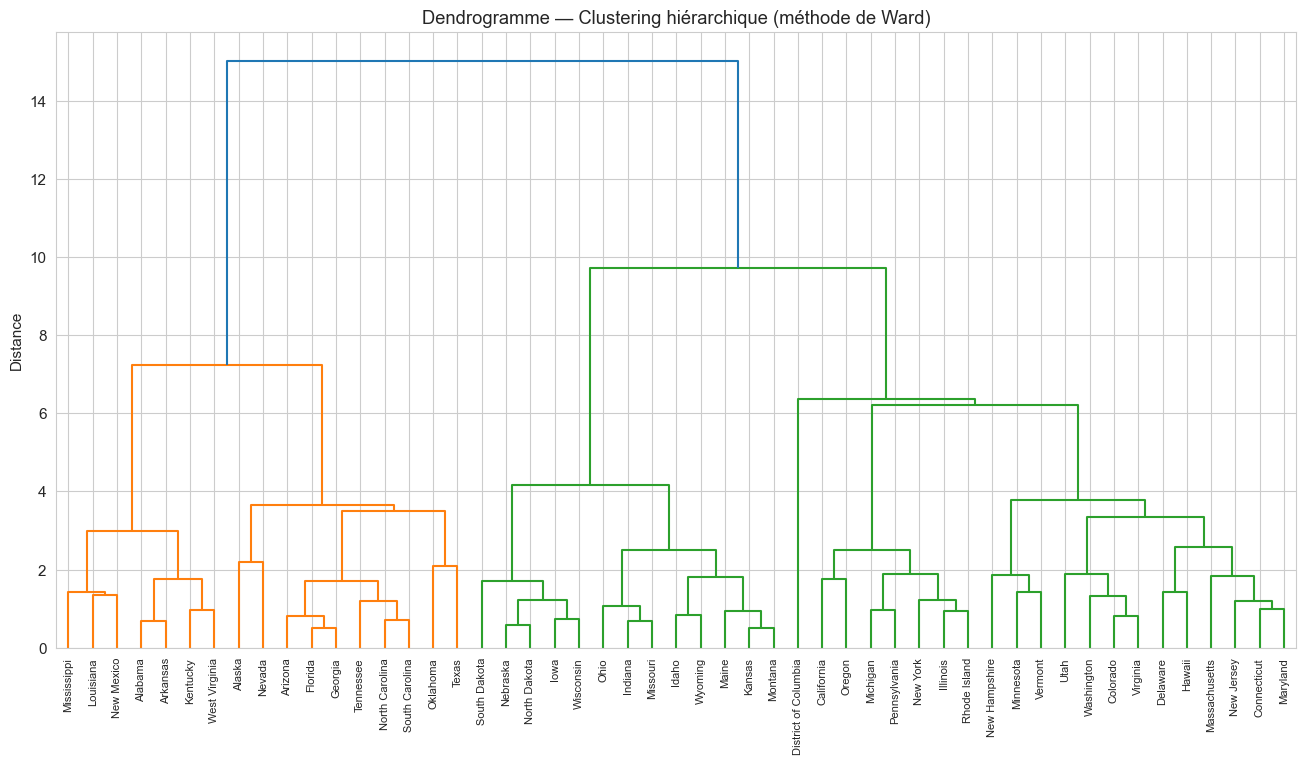

In [43]:
# === CELL 35: Hierarchical Clustering ===
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(X_scaled, method='ward')

# Dendrogramme
fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(Z, labels=state_profile['State'].values, leaf_rotation=90, leaf_font_size=8, ax=ax)
ax.set_title('Dendrogramme — Clustering hiérarchique (méthode de Ward)')
ax.set_ylabel('Distance')
plt.show()

Silhouette K-Means  : 0.283
Silhouette Hiérarch.: 0.264


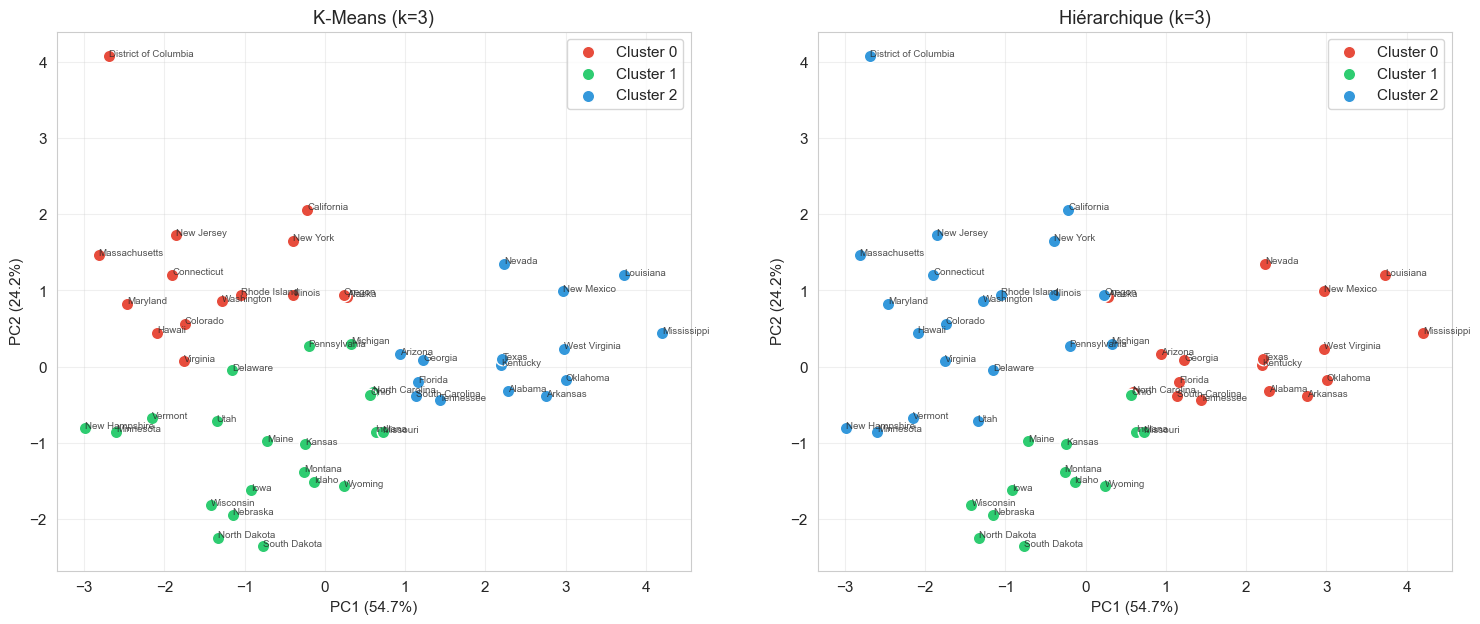


États par cluster (K-Means) :
  Vulnérables (15 États) : Alabama, Arizona, Arkansas, Florida, Georgia, Kentucky, Louisiana, Mississippi, Nevada, New Mexico, Oklahoma, South Carolina, Tennessee, Texas, West Virginia
  Intermédiaires (21 États) : Delaware, Idaho, Indiana, Iowa, Kansas, Maine, Michigan, Minnesota, Missouri, Montana, Nebraska, New Hampshire, North Carolina, North Dakota, Ohio, Pennsylvania, South Dakota, Utah, Vermont, Wisconsin, Wyoming
  Favorisés (15 États) : Alaska, California, Colorado, Connecticut, District of Columbia, Hawaii, Illinois, Maryland, Massachusetts, New Jersey, New York, Oregon, Rhode Island, Virginia, Washington


In [44]:
# === CELL 36: Compare K-Means vs Hierarchical ===
state_profile['cluster_hier'] = fcluster(Z, t=k_opt, criterion='maxclust') - 1

sil_hier = silhouette_score(X_scaled, state_profile['cluster_hier'])
print(f"Silhouette K-Means  : {sil:.3f}")
print(f"Silhouette Hiérarch.: {sil_hier:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
color_list = ['#e74c3c', '#2ecc71', '#3498db']

for ax, col, title in zip(axes, ['cluster_kmeans', 'cluster_hier'],
                           [f'K-Means (k={k_opt})', f'Hiérarchique (k={k_opt})']):
    for c in range(k_opt):
        mask = state_profile[col] == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=80, color=color_list[c],
                   edgecolors='white', label=f'Cluster {c}')
        for i in state_profile[mask].index:
            ax.annotate(state_profile.loc[i, 'State'],
                        (X_pca[i, 0], X_pca[i, 1]), fontsize=7, alpha=0.8)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.show()

print("\nÉtats par cluster (K-Means) :")
for label in ['Vulnérables', 'Intermédiaires', 'Favorisés']:
    states = state_profile[state_profile['cluster_label'] == label]['State'].tolist()
    print(f"  {label} ({len(states)} États) : {', '.join(states)}")